# Libreries

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from scipy.stats import ttest_rel
import shap
import lightgbm as lgb
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import mannwhitneyu

# Problem Understanding

In [200]:
df = pd.read_excel('C:/Users/fccat/Desktop/MUDI Lab/Data/Data.xlsx', sheet_name='Foglio1')
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,...,M Letto-sedia-carrozzina_post_int,M WC_post_int,M Vasca o doccia_post_int,C Rapporto con gli altri_post_int,C Soluzione di problemi_post_int,C Memoria_post_int,Autonomia Deambulazione,Ausili,Outcome sociale,Peso Assistenziale
0,Monza e Brianza,715.15,81.51,postero-laterale,79,F,Pensionato che ha lavorato,28.0,5,2,...,7,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,6,6,2,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,6,6,1,7.0,7.0,7.0,Con supervisore,2 canadesi,Domicilio con parenti,Meno di 3h
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,7,6,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1706,Savona,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,...,7,6,4,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1707,Milano,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,...,6,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
1708,Cuneo,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h


In [201]:

# -------------------------------
# 2️⃣ Analisi dei Missing Values
# -------------------------------
print("\n🔎 Analisi dei valori mancanti:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Values': missing_values,
    '% Missing': missing_percent.round(2)
})
display(missing_report[missing_report['Missing Values'] > 0].sort_values('% Missing', ascending=False))


🔎 Analisi dei valori mancanti:


,Missing Values,% Missing
Condizioni pre-esistenti 9,1709,99.94
Condizioni pre-esistenti 8,1709,99.94
Condizioni pre-esistenti 7,1709,99.94
Condizioni pre-esistenti 6,1703,99.59
Condizioni pre-esistenti 5,1676,98.01
Condizioni pre-esistenti 4,1616,94.50
Condizioni pre-esistenti 3,1381,80.76
Condizioni pre-esistenti 2,921,53.86
CPM,646,37.78
Terapia farmacologica,357,20.88


In [202]:
# -------------------------------
# 3️⃣ Tipi di variabili e possibili problemi di tipo
# -------------------------------
print("\n⚙️ Tipi di variabili:")
display(df.dtypes)

# Individua variabili numeriche salvate come 'object' (potenziali problemi)
print("\n🚨 Variabili 'object' che potrebbero essere numeriche:")
possible_numeric = df.select_dtypes('object').apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull().any()
display(df.select_dtypes('object').columns[possible_numeric].tolist())


⚙️ Tipi di variabili:


Residenza                               object
Diagnosi alla dimissione (ICD code)    float64
Procedura (ICD code)                   float64
Accesso chirurgico                      object
Età                                      int64
                                        ...   
C Memoria_post_int                     float64
Autonomia Deambulazione                 object
Ausili                                  object
Outcome sociale                         object
Peso Assistenziale                      object
Length: 63, dtype: object


🚨 Variabili 'object' che potrebbero essere numeriche:


['M Letto-sedia-carrozzina',
 'M WC',
 'M Vasca o doccia',
 'Hb ingresso',
 'Giorni_vert_intervento',
 'M Letto-sedia-carrozzina_post_int',
 'M WC_post_int',
 'M Vasca o doccia_post_int']

In [203]:
# -------------------------------
# 4️⃣ Codifica delle variabili categoriche
# -------------------------------
print("\n🔤 Analisi delle variabili categoriche:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\n🧩 Colonna: {col}")
    print(df[col].value_counts(dropna=False).head(10))  # Mostra le prime 10 modalità


🔤 Analisi delle variabili categoriche:



🧩 Colonna: Residenza
Residenza
Genova             380
Milano             351
Monza e Brianza     93
Como                59
Varese              56
Savona              54
Roma                51
Alessandria         50
Napoli              35
Lecco               33
Name: count, dtype: int64

🧩 Colonna: Accesso chirurgico
Accesso chirurgico
midvastus           659
postero-laterale    576
pararotuleo         414
anteriore            50
laterale diretto      9
NaN                   2
Name: count, dtype: int64

🧩 Colonna: Sesso
Sesso
F     1066
M      628
M       10
F        6
Name: count, dtype: int64

🧩 Colonna: Professione
Professione
Pensionato che ha lavorato                             1014
Casalinga (che ha svolto lavoro retribuito)             179
Operaio, salariato agricolo, altro lavoratore           135
Impiegato, insegnante                                    96
Imprenditore - Libero Professionista                     81
Casalinga (che non ha mai svolto lavoro retribuito)      60
D

# Data Understanding

Average Age and Age variability

In [204]:
# Analisi dell'età
age_mean = df['Età'].mean()
age_std = df['Età'].std()
age_median = df['Età'].median()
age_iqr = df['Età'].quantile(0.75) - df['Età'].quantile(0.25)

print(f"Età media: {age_mean:.2f}")
print(f"Deviazione standard: {age_std:.2f}")
print(f"Mediana: {age_median:.2f}")
print(f"IQR: {age_iqr:.2f}")


Età media: 69.40
Deviazione standard: 10.73
Mediana: 70.00
IQR: 15.00


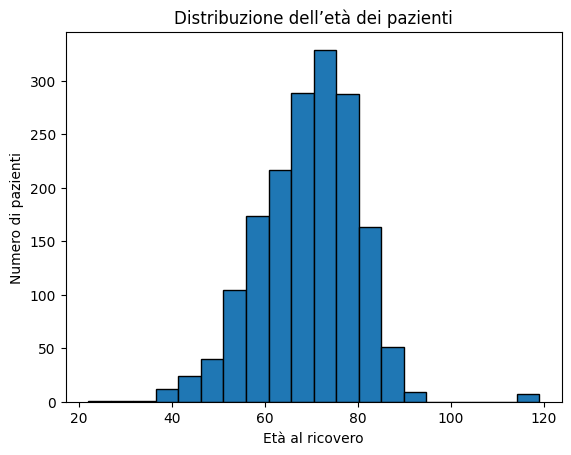

In [205]:
# Istogramma età
df['Età'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel("Età al ricovero")
plt.ylabel("Numero di pazienti")
plt.title("Distribuzione dell’età dei pazienti")
plt.show()

Gender breakdown

In [206]:
# Distribuzione del sesso
gender_counts = df['Sesso'].value_counts(dropna=False)
gender_percent = df['Sesso'].value_counts(normalize=True, dropna=False) * 100

print("Distribuzione sesso (conteggio):")
print(gender_counts)
print("\nDistribuzione sesso (%):")
print(gender_percent.round(2))


Distribuzione sesso (conteggio):
Sesso
F     1066
M      628
M       10
F        6
Name: count, dtype: int64

Distribuzione sesso (%):
Sesso
F     62.34
M     36.73
M      0.58
F      0.35
Name: proportion, dtype: float64


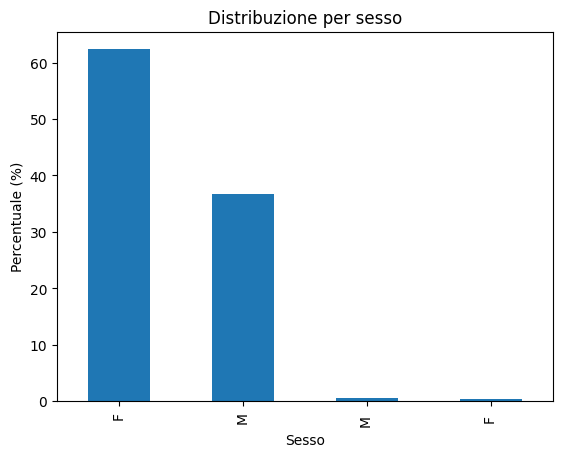

In [207]:
# Bar plot sesso
gender_percent.plot(kind='bar')
plt.ylabel("Percentuale (%)")
plt.title("Distribuzione per sesso")
plt.show()

Main comorbidities

In [208]:
# Seleziona tutte le colonne relative alle condizioni preesistenti
comorb_cols = [col for col in df.columns if "Condizioni pre-esistenti" in col]

# Unisci tutte le colonne in un'unica serie
comorbidities = pd.Series(df[comorb_cols].values.ravel())

# Rimuovi missing e normalizza
comorbidities = comorbidities.dropna().str.strip().str.title()

# Conta la frequenza delle comorbidità
main_comorbidities = comorbidities.value_counts().head(10)
less_comorbidities = comorbidities.value_counts().sort_values(ascending=True).head(10)
print("Le 10 comorbidità più frequenti:")
print(main_comorbidities)
print("Le 10 comorbidità meno frequenti:")
print(less_comorbidities)


Le 10 comorbidità più frequenti:
Ipertensione Arteriosa    988
Malattie Della Tiroide    237
Altro Cardiovascolare     199
Diabete 2                 192
Ipercol. E/O Ipertrig.    159
Dislipidemia              127
Psiche                    118
Fibrillazione Atriale      88
Osteoporosi                55
Asma                       50
Name: count, dtype: int64
Le 10 comorbidità meno frequenti:
Altro Sistema Urinario                1
Tumori                                1
Visivo                                1
Malattie Della Tioride                1
Altro Cute Ed Annessi                 1
Altro Sistema Nervoso Periferico      1
Tiroide                               2
Altro Sistema Endocrino-Metabolico    5
Altro Sistema Emolinfopoietico        7
Parkinson                             9
Name: count, dtype: int64


Ethnic group

In [209]:
# Distribuzione geografica
residenza_counts = df['Residenza'].value_counts().head(10)
residenza_percent = df['Residenza'].value_counts(normalize=True).head(10) * 100

print("Principali province di residenza:")
print(pd.DataFrame({
    'Conteggio': residenza_counts,
    'Percentuale': residenza_percent.round(2)
}))


Principali province di residenza:
                 Conteggio  Percentuale
Residenza                              
Genova                 380        22.22
Milano                 351        20.53
Monza e Brianza         93         5.44
Como                    59         3.45
Varese                  56         3.27
Savona                  54         3.16
Roma                    51         2.98
Alessandria             50         2.92
Napoli                  35         2.05
Lecco                   33         1.93


Socioeconomic status

In [210]:
# Distribuzione per professione
print("Distribuzione professione:")
print(df['Professione'].value_counts(dropna=False).head(10))

# Distribuzione per stato abitativo
print("\nDistribuzione 'Vive con':")
print(df['Vive con'].value_counts(dropna=False))


Distribuzione professione:
Professione
Pensionato che ha lavorato                             1014
Casalinga (che ha svolto lavoro retribuito)             179
Operaio, salariato agricolo, altro lavoratore           135
Impiegato, insegnante                                    96
Imprenditore - Libero Professionista                     81
Casalinga (che non ha mai svolto lavoro retribuito)      60
Disoccupato (attualmente)                                59
Altro (che ha svolto lavoro retribuito)                  32
Artigiano, coltivatore diretto, commerciante             25
Invalido, inabile (anche se pensionato)                   8
Name: count, dtype: int64

Distribuzione 'Vive con':
Vive con
Familiari                                                 1391
Da solo, ≥65                                               254
Da solo                                                     43
 ≥65 anni e vive con familiare/caregiver in difficoltà      10
≥65 anni e vive con familiare/caregiver in diff

Verifica completezza dei target

In [211]:
# Lista dei target principali
target_cols = [
    'Durata CC riabilitazione',
    'Outcome sociale',
    'Peso Assistenziale',
    'BI_post_int',  # Barthel Index
    'FIM_post_int',  # Functional Independence Measure
    "Autonomia Deambulazione",
    "Ausili"
]

# Percentuale di valori mancanti per ciascun target
missing_targets = df[target_cols].isna().mean() * 100
print("Percentuale di valori mancanti nei target (%):")
print(missing_targets.round(2))


Percentuale di valori mancanti nei target (%):
Durata CC riabilitazione    0.06
Outcome sociale             0.06
Peso Assistenziale          0.06
BI_post_int                 0.06
FIM_post_int                0.06
Autonomia Deambulazione     0.06
Ausili                      0.06
dtype: float64


Analisi di base per ogni target

In [212]:
# Variabili continue
continuous_targets = ['Durata CC riabilitazione', 'BI_post_int', 'FIM_post_int']

for col in continuous_targets:
    print(f"\n--- {col} ---")
    print(f"Media: {df[col].mean():.2f}")
    print(f"Deviazione standard: {df[col].std():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"IQR: {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")



--- Durata CC riabilitazione ---
Media: 10.28
Deviazione standard: 3.72
Mediana: 10.00
Min: 1.0, Max: 34.0
IQR: 5.00

--- BI_post_int ---
Media: 95.71
Deviazione standard: 6.30
Mediana: 97.00
Min: 27.0, Max: 108.0
IQR: 4.00

--- FIM_post_int ---
Media: 116.48
Deviazione standard: 6.07
Mediana: 117.00
Min: 59.0, Max: 129.0
IQR: 6.00


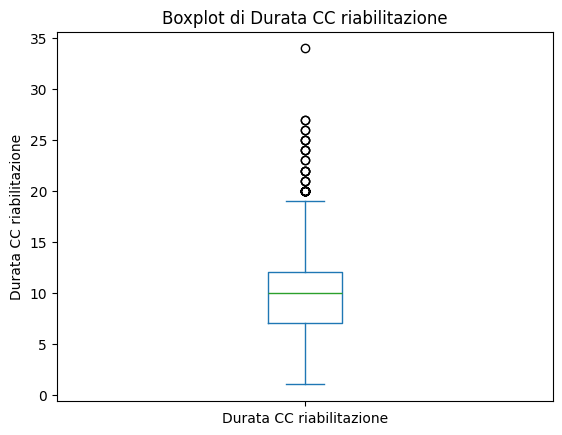

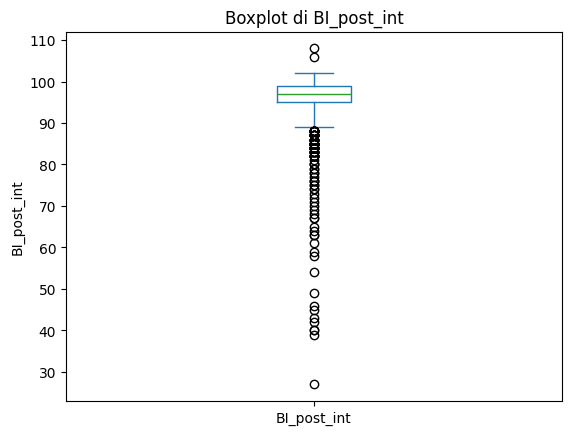

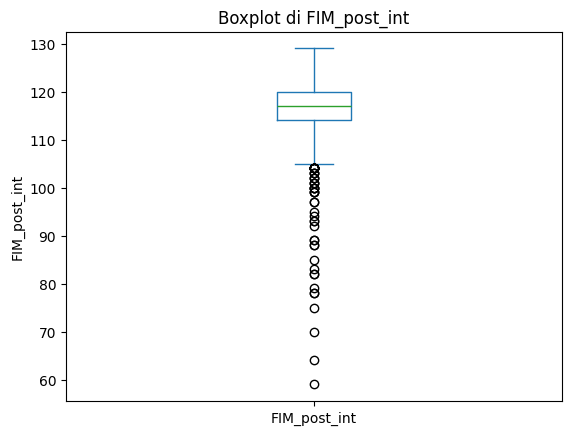

In [213]:
for col in continuous_targets:
    df[col].plot(kind='box', title=f"Boxplot di {col}")
    plt.ylabel(col)
    plt.show()

In [214]:
# Variabili categoriali
categorical_targets = ['Outcome sociale', 'Peso Assistenziale', "Autonomia Deambulazione", "Ausili"]

for col in categorical_targets:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print("\nDistribuzione (%):")
    print(df[col].value_counts(normalize=True, dropna=False).round(3) * 100)



--- Outcome sociale ---
Outcome sociale
Domicilio con parenti    1549
Domicilio da solo         101
Istituto                   59
NaN                         1
Name: count, dtype: int64

Distribuzione (%):
Outcome sociale
Domicilio con parenti    90.6
Domicilio da solo         5.9
Istituto                  3.5
NaN                       0.1
Name: proportion, dtype: float64

--- Peso Assistenziale ---
Peso Assistenziale
Meno di 3h        1307
Nessuno            396
Meno di 6h           4
Giorno e notte       2
NaN                  1
Name: count, dtype: int64

Distribuzione (%):
Peso Assistenziale
Meno di 3h        76.4
Nessuno           23.2
Meno di 6h         0.2
Giorno e notte     0.1
NaN                0.1
Name: proportion, dtype: float64

--- Autonomia Deambulazione ---
Autonomia Deambulazione
Autonomo           1606
Autonoma <50m        71
Con supervisore      29
Impossibile           3
NaN                   1
Name: count, dtype: int64

Distribuzione (%):
Autonomia Deambulazione
Au

## Feature Description

In [215]:
# Escludiamo i target

# Seleziona solo le feature
features = [col for col in df.columns if col not in target_cols]

print(f"Numero totale di feature: {len(features)}")

Numero totale di feature: 56


Classificazione automatica del tipo di variabile

In [216]:
# Rilevamento automatico del tipo di variabile
feature_types = {}

for col in features:
    unique_vals = df[col].nunique()
    if pd.api.types.is_numeric_dtype(df[col]):
        feature_types[col] = "continuous"
    elif unique_vals <= 10:
        feature_types[col] = "categorical (nominal)"
    else:
        feature_types[col] = "categorical (textual/mixed)"

feature_types_df = pd.DataFrame.from_dict(feature_types, orient='index', columns=['Type'])
print("Tipologia di variabili:")
print(feature_types_df.head)


Tipologia di variabili:
<bound method NDFrame.head of                                                                            Type
Residenza                                           categorical (textual/mixed)
Diagnosi alla dimissione (ICD code)                                  continuous
Procedura (ICD code)                                                 continuous
Accesso chirurgico                                        categorical (nominal)
Età                                                                  continuous
Sesso                                                     categorical (nominal)
Professione                                         categorical (textual/mixed)
BMI Pre-Int                                                          continuous
Durata ricovero                                                      continuous
ASA                                                                  continuous
Durata intervento                                                 

Statistiche descrittive per variabili continue

In [217]:
# Statistiche per variabili continue
continuous_features = [col for col, t in feature_types.items() if t == "continuous"]

desc_cont = df[continuous_features].describe(percentiles=[0.25, 0.5, 0.75]).T
desc_cont['IQR'] = desc_cont['75%'] - desc_cont['25%']
desc_cont = desc_cont[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']]
desc_cont.rename(columns={'50%': 'median'}, inplace=True)

print("Statistiche descrittive per variabili continue:")
print(desc_cont.round(2))


Statistiche descrittive per variabili continue:
                                       mean    std     min     25%  median  \
Diagnosi alla dimissione (ICD code)  715.16   0.02  715.15  715.15  715.16   
Procedura (ICD code)                  81.53   0.01   81.51   81.51   81.54   
Età                                   69.40  10.73   22.00   62.00   70.00   
BMI Pre-Int                           28.23   5.02   16.00   25.00   28.00   
Durata ricovero                        4.77   1.41    3.00    4.00    5.00   
ASA                                    1.95   0.35    1.00    2.00    2.00   
Durata intervento                     62.64  31.70    0.00   41.00   54.00   
BI                                    70.28  12.01   13.00   63.00   69.00   
FIM                                   96.66   9.16   34.00   92.00   98.00   
C Rapporto con gli altri               6.99   0.19    1.00    7.00    7.00   
C Soluzione di problemi                6.97   0.27    1.00    7.00    7.00   
C Memoria       

Distribuzione per variabili categoriali

In [218]:
# Statistiche per variabili categoriali
categorical_features = [col for col, t in feature_types.items() if "categorical" in t]

for col in categorical_features:
    print(f"\n--- {col} ---")
    counts = df[col].value_counts(dropna=False)
    percent = df[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'Count': counts, 'Percent': percent.round(2)})
    print(summary.head(10))



--- Residenza ---
                 Count  Percent
Residenza                      
Genova             380    22.22
Milano             351    20.53
Monza e Brianza     93     5.44
Como                59     3.45
Varese              56     3.27
Savona              54     3.16
Roma                51     2.98
Alessandria         50     2.92
Napoli              35     2.05
Lecco               33     1.93

--- Accesso chirurgico ---
                    Count  Percent
Accesso chirurgico                
midvastus             659    38.54
postero-laterale      576    33.68
pararotuleo           414    24.21
anteriore              50     2.92
laterale diretto        9     0.53
NaN                     2     0.12

--- Sesso ---
       Count  Percent
Sesso                
F       1066    62.34
M        628    36.73
M         10     0.58
F          6     0.35

--- Professione ---
                                                    Count  Percent
Professione                                           

Visualizzazioni — violin plots per alcune variabili continue

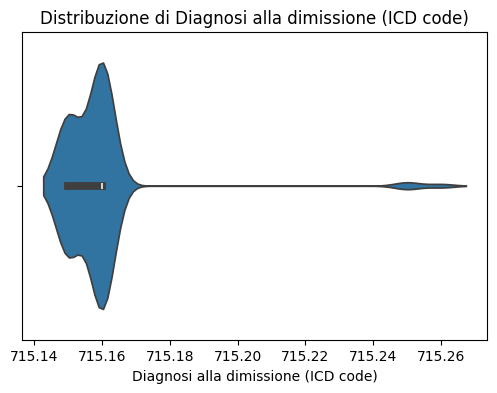

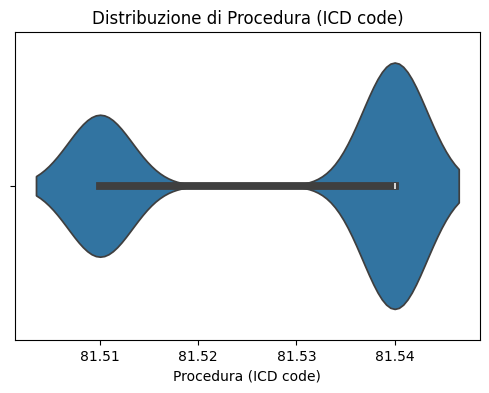

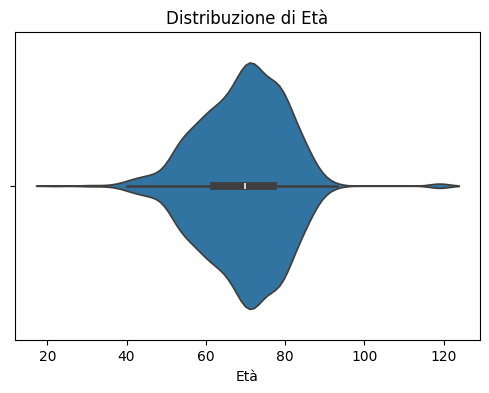

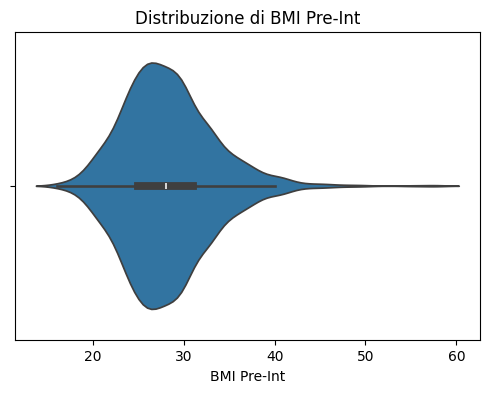

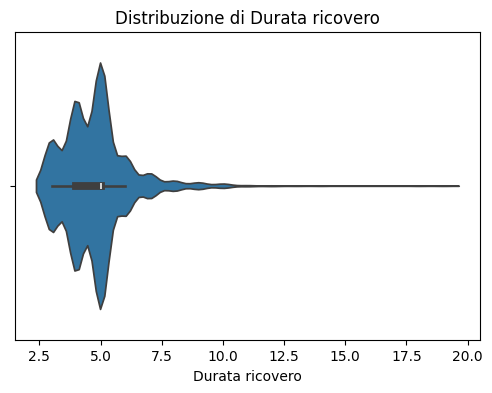

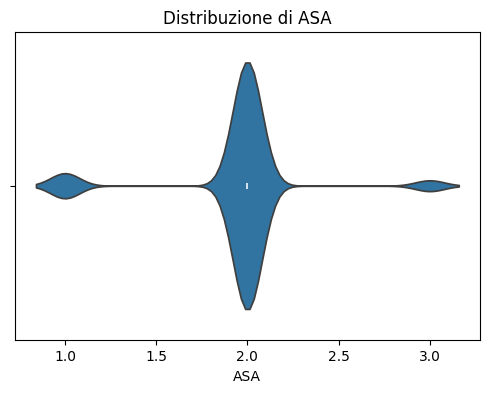

In [219]:
# Violin plots per alcune feature numeriche rilevanti
sample_cont = continuous_features[:6]  # prendi le prime 6 per esempio

for col in sample_cont:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x=df[col])
    plt.title(f"Distribuzione di {col}")
    plt.xlabel(col)
    plt.show()


Tabella riassuntiva

In [220]:
# Crea un DataFrame riassuntivo unendo tipo + statistiche di base
summary_df = feature_types_df.copy()

summary_df['n_missing'] = df[features].isna().sum()
summary_df['missing_%'] = (summary_df['n_missing'] / len(df)) * 100
summary_df['unique_values'] = df[features].nunique()

summary_df.to_excel("C:/Users/fccat/Desktop/MUDI Lab/Reports/feature_summary.xlsx", index=True)
print("Tabella riassuntiva delle feature salvata come 'feature_summary.xlsx'")

Tabella riassuntiva delle feature salvata come 'feature_summary.xlsx'


In [221]:
summary_df

,Type,n_missing,missing_%,unique_values
Residenza,categorical (textual/mixed),0,0.000000,94
Diagnosi alla dimissione (ICD code),continuous,0,0.000000,4
Procedura (ICD code),continuous,0,0.000000,2
Accesso chirurgico,categorical (nominal),2,0.116959,5
Età,continuous,0,0.000000,60
Sesso,categorical (nominal),0,0.000000,4
Professione,categorical (textual/mixed),0,0.000000,18
BMI Pre-Int,continuous,4,0.233918,38
Durata ricovero,continuous,0,0.000000,14
ASA,continuous,0,0.000000,3


In [222]:
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,...,M Letto-sedia-carrozzina_post_int,M WC_post_int,M Vasca o doccia_post_int,C Rapporto con gli altri_post_int,C Soluzione di problemi_post_int,C Memoria_post_int,Autonomia Deambulazione,Ausili,Outcome sociale,Peso Assistenziale
0,Monza e Brianza,715.15,81.51,postero-laterale,79,F,Pensionato che ha lavorato,28.0,5,2,...,7,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
1,Como,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,...,6,6,2,7.0,7.0,7.0,Autonomo,2 canadesi,Istituto,Meno di 3h
2,Monza e Brianza,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
3,Milano,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,...,6,6,1,7.0,7.0,7.0,Con supervisore,2 canadesi,Domicilio con parenti,Meno di 3h
4,Milano,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,...,7,6,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,Varese,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1706,Savona,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,...,7,6,4,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h
1707,Milano,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,...,6,6,5,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Nessuno
1708,Cuneo,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,...,7,7,1,7.0,7.0,7.0,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h


Seleziono solo le variabili di mio interesse

In [223]:
# Lista delle feature principali selezionate
feature_columns = [
    'Diagnosi alla dimissione (ICD code)',
    'Procedura (ICD code)',
    'Accesso chirurgico',
    'Età',
    'Sesso',
    'Professione',
    'BMI Pre-Int',
    'Durata ricovero',
    'ASA',
    'Durata intervento',
    'Anestesia',
    'Rischio bio',
    'Trasfusione',
    'BI',
    'FIM',
    'ADL',
    'L Autonomia passaggi posturali',
    'Ausili Deambulazione',
    'Vive con',
    'Dolore ingresso (VNS)',
    'Precedente protesi',
    'Condizioni pre-esistenti 1', "Condizioni pre-esistenti 2", "Condizioni pre-esistenti 3", "Condizioni pre-esistenti 4", 
    "Condizioni pre-esistenti 5", "Condizioni pre-esistenti 6", "Condizioni pre-esistenti 7", "Condizioni pre-esistenti 8",
    "Condizioni pre-esistenti 9",
    'Terapia farmacologica',
    'Farmaci extra',
    'Hb ingresso'
]

# Lista dei target
target_columns = [
    'Durata CC riabilitazione',  # Outcome primario (regressorio)
    'Outcome sociale',                    # Outcome secondario (classificatorio)
    'Peso Assistenziale',                 # Outcome secondario (classificatorio)
    'BI_post_int',                        # Barthel Index post intervento (regressorio)
    'FIM_post_int',                       # FIM post intervento (regressorio)
    'Autonomia Deambulazione',                       # Eventuale (classificatorio)
    'Ausili'                               # Eventuale (classificatorio)
]

# Creazione del nuovo dataset
columns_to_keep = feature_columns + target_columns
df_selected = df[columns_to_keep]

# Controllo del nuovo dataset
print(df_selected)
print(f"Shape del nuovo dataset: {df_selected.shape}")

# Salvataggio opzionale in CSV
df_selected.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Dataset_features_target.csv', index=False)

      Diagnosi alla dimissione (ICD code)  Procedura (ICD code)  \
0                                  715.15                 81.51   
1                                  715.16                 81.54   
2                                  715.16                 81.54   
3                                  715.15                 81.51   
4                                  715.16                 81.54   
...                                   ...                   ...   
1705                               715.15                 81.51   
1706                               715.16                 81.54   
1707                               715.25                 81.51   
1708                               715.16                 81.54   
1709                               715.25                 81.51   

     Accesso chirurgico  Età Sesso                           Professione  \
0      postero-laterale   79     F            Pensionato che ha lavorato   
1           pararotuleo   79     F         

# Data Preparation

In [224]:
df=pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Dataset_features_target.csv')
df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Terapia farmacologica,Farmaci extra,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili
0,715.15,81.51,postero-laterale,79,F,Pensionato che ha lavorato,28.0,5,2,93.0,...,Sì,No,9.9,12.0,Istituto,Meno di 3h,99.0,119.0,Autonomo,2 canadesi
1,715.16,81.54,pararotuleo,79,F,Pensionato che ha lavorato,24.0,6,2,95.0,...,In parte,No,9.4,15.0,Istituto,Meno di 3h,84.0,109.0,Autonomo,2 canadesi
2,715.16,81.54,pararotuleo,73,F,Pensionato che ha lavorato,26.0,6,2,121.0,...,Sì,No,9.0,16.0,Domicilio con parenti,Meno di 3h,100.0,118.0,Autonomo,2 canadesi
3,715.15,81.51,postero-laterale,73,F,Pensionato che ha lavorato,23.0,6,1,88.0,...,NaN,No,10.1,10.0,Domicilio con parenti,Meno di 3h,84.0,107.0,Con supervisore,2 canadesi
4,715.16,81.54,pararotuleo,81,F,Pensionato che ha lavorato,38.0,6,2,99.0,...,In parte,No,8.8,20.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,715.15,81.51,anteriore,63,M,Pensionato che ha lavorato,26.0,5,1,68.0,...,NaN,No,12.1,12.0,Domicilio con parenti,Meno di 3h,99.0,115.0,Autonomo,2 canadesi
1706,715.16,81.54,pararotuleo,60,M,Imprenditore - Libero Professionista,26.0,3,2,31.0,...,NaN,No,10.6,6.0,Domicilio con parenti,Meno di 3h,95.0,118.0,Autonomo,2 canadesi
1707,715.25,81.51,laterale diretto,79,F,Pensionato che ha lavorato,21.0,5,2,96.0,...,Sì,No,9.3,13.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
1708,715.16,81.54,pararotuleo,49,M,Imprenditore - Libero Professionista,24.0,4,2,72.0,...,NaN,No,10,5.0,Domicilio con parenti,Meno di 3h,97.0,112.0,Autonomo,2 canadesi


## Data Cleaning


Controllo duplicati


In [225]:
# Quante righe duplicate ci sono?
print("Numero duplicati:", df.duplicated().sum())

# Rimuovere duplicati se presenti
df.drop_duplicates(inplace=True)

Numero duplicati: 0


Diagnosi alla dimissione (ICD code)


In [226]:
df["Diagnosi alla dimissione (ICD code)"].dtypes


dtype('float64')

In [227]:
# Convertire in object
df["Diagnosi alla dimissione (ICD code)"] = df["Diagnosi alla dimissione (ICD code)"].astype(str)
df["Diagnosi alla dimissione (ICD code)"].dtypes


dtype('O')

In [228]:
df["Diagnosi alla dimissione (ICD code)"].unique()

array(['715.15', '715.16', '715.25', '715.26'], dtype=object)

Procedura (ICD code)


In [229]:
df["Procedura (ICD code)"].dtypes


dtype('float64')

In [230]:
# Convertire in object
df["Procedura (ICD code)"] = df["Procedura (ICD code)"].astype(str)
df["Procedura (ICD code)"].dtypes

dtype('O')

In [231]:
df["Procedura (ICD code)"].unique()

array(['81.51', '81.54'], dtype=object)

Accesso chirurgico


In [232]:
df["Accesso chirurgico"].dtypes


dtype('O')

In [233]:
df["Accesso chirurgico"].unique()


array(['postero-laterale', 'pararotuleo', 'anteriore', 'midvastus',
       'laterale diretto', nan], dtype=object)

Età


In [234]:
df["Età"].dtypes


dtype('int64')

In [235]:
df["Età"].unique()


array([ 79,  73,  81,  51,  74,  84,  76,  80,  41,  69,  89,  78,  71,
        59,  62,  63,  56,  77,  86,  64,  66,  85,  75,  60,  70,  58,
        82,  87,  55,  67,  53,  46,  44,  57,  61,  72,  32,  48,  83,
        91,  65,  68,  43,  52,  54,  90,  88,  49,  37,  40,  50,  47,
       119,  22,  39,  45,  42,  92,  93,  30])

Sesso


In [236]:
df["Sesso"].dtypes


dtype('O')

In [237]:
df["Sesso"].unique()


array(['F', 'F ', 'M', 'M '], dtype=object)

In [238]:
# Rimuove spazi iniziali/finali e uniforma maiuscole
df['Sesso'] = df['Sesso'].str.strip().str.upper()
df["Sesso"].unique()

array(['F', 'M'], dtype=object)

Professione

In [239]:
df["Professione"].dtypes


dtype('O')

In [240]:
df["Professione"].unique()


array(['Pensionato che ha lavorato', 'Disoccupato (attualmente)',
       'Casalinga (che non ha mai svolto lavoro retribuito)',
       'Impiegato, insegnante',
       'Altro (che non ha mai svolto lavoro retribuito)',
       'Operaio, salariato agricolo, altro lavoratore', 'Dirigente',
       'Casalinga (che ha svolto lavoro retribuito)',
       'Imprenditore - Libero Professionista',
       'Invalido, inabile (anche se pensionato)',
       'Artigiano, coltivatore diretto, commerciante',
       'Altro (che ha svolto lavoro retribuito)',
       'Artigiano, Coltivatore Diretto, Commerciante',
       'Casalinga (che non ha mai ha svolto lavoro retribuito)',
       'pensionato che ha lavorato', 'Lavorante a domicilio',
       'Coadiuvante in aziende a conduzione familiare',
       'altro (che ha svolto lavoro retribuito)'], dtype=object)

In [241]:
df['Professione'] = df['Professione'].str.strip().str.title()
df['Professione'] = df['Professione'].replace({
    'Pensionato Che Ha Lavorato': 'Pensionato che ha lavorato',
    'Altro (Che Ha Svolto Lavoro Retribuito)': 'Altro (che ha svolto lavoro retribuito)',
    'Casalinga (Che Non Ha Mai Ha Svolto Lavoro Retribuito)': 'Casalinga (che non ha mai svolto lavoro retribuito)',
    'Artigiano, Coltivatore Diretto, Commerciante': 'Artigiano, coltivatore diretto, commerciante'
})
df["Professione"].unique()

array(['Pensionato che ha lavorato', 'Disoccupato (Attualmente)',
       'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Impiegato, Insegnante',
       'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Operaio, Salariato Agricolo, Altro Lavoratore', 'Dirigente',
       'Casalinga (Che Ha Svolto Lavoro Retribuito)',
       'Imprenditore - Libero Professionista',
       'Invalido, Inabile (Anche Se Pensionato)',
       'Artigiano, coltivatore diretto, commerciante',
       'Altro (che ha svolto lavoro retribuito)',
       'Casalinga (che non ha mai svolto lavoro retribuito)',
       'Lavorante A Domicilio',
       'Coadiuvante In Aziende A Conduzione Familiare'], dtype=object)

In [242]:
df['Professione'] = df['Professione'].replace({
    'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)': 'Casalinga (che non ha mai svolto lavoro retribuito)',
    'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)': 'Altro (che non ha mai svolto lavoro retribuito)',
    'Casalinga (Che Ha Svolto Lavoro Retribuito)': 'Casalinga (che ha svolto lavoro retribuito)',
    'Altro (Che Ha Svolto Lavoro Retribuito)': 'Altro (che ha svolto lavoro retribuito)',
})
df['Professione'] = df['Professione'].str.title()
df["Professione"].unique()

array(['Pensionato Che Ha Lavorato', 'Disoccupato (Attualmente)',
       'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Impiegato, Insegnante',
       'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Operaio, Salariato Agricolo, Altro Lavoratore', 'Dirigente',
       'Casalinga (Che Ha Svolto Lavoro Retribuito)',
       'Imprenditore - Libero Professionista',
       'Invalido, Inabile (Anche Se Pensionato)',
       'Artigiano, Coltivatore Diretto, Commerciante',
       'Altro (Che Ha Svolto Lavoro Retribuito)', 'Lavorante A Domicilio',
       'Coadiuvante In Aziende A Conduzione Familiare'], dtype=object)

BMI Pre-Int


In [243]:
df["BMI Pre-Int"].dtypes


dtype('float64')

In [244]:
df["BMI Pre-Int"].unique()


array([28., 24., 26., 23., 38., 25., 17., 43., 27., 32., 21., 33., 20.,
       30., 37., 41., 40., 31., 22., 29., 35., 34., 18., 44., 39., 36.,
       49., nan, 42., 16., 19., 46., 58., 45., 57., 55., 50., 48., 47.])

Durata ricovero pre int


In [245]:
df["Durata ricovero"].dtypes


dtype('int64')

In [246]:
df["Durata ricovero"].unique()


array([ 5,  6,  7,  4,  9,  8, 14,  3, 10, 11, 12, 13, 18, 19])

ASA


In [247]:
df["ASA"].dtypes


dtype('int64')

In [248]:
# Convertire in object
df['ASA'] = df['ASA'].astype(str)
df["ASA"].dtypes

dtype('O')

In [249]:
df["ASA"].unique()


array(['2', '1', '3'], dtype=object)

Durata intervento


In [250]:
df["Durata intervento"].dtypes


dtype('float64')

In [251]:
df["Durata intervento"].unique()


array([ 93.,  95., 121.,  88.,  99., 123., 106., 134., 110.,  66.,  75.,
       120.,  77., 151., 142.,  97., 105.,  76., 126.,  86.,  84.,  98.,
       150.,  58.,  82.,  74., 112., 109., 119., 114.,  80.,  79.,  78.,
       117.,  90.,  72., 100., 140., 101., 103., 107., 143.,  73., 139.,
        89., 133., 155.,  92., 104.,  69.,  85.,  60., 125., 113., 215.,
       169., 102.,  94., 111., 386.,  68., 115.,  96., 153., 146., 135.,
        63., 127., 108.,  87.,  56., 130.,  91., 212., 136.,  50.,  44.,
        30.,  65.,  33.,  41.,  59.,  64.,  38.,  47.,  42.,  43.,  27.,
        53.,  57.,  51.,  61.,  35.,  26.,  32.,  70.,  48.,  18.,  52.,
        28.,  39.,  46.,  36.,  31.,  81., 161.,  71., 118., 244.,  40.,
        37.,  34.,  24.,  54.,  23.,  67.,  62.,  55., 122.,  45.,  25.,
        83., 129.,  49.,  22.,  29.,  14., 116.,  16., 162., 141.,   4.,
       137., 154.,  nan,  19., 144., 197., 131., 148., 174.,   1.,   0.,
       124.,  21.,   8., 164., 138., 188., 200.,   

In [252]:
# Sostituire valori improbabili con NaN
df.loc[(df['Durata intervento'] < 20)] = np.nan
df["Durata intervento"].unique()

array([ 93.,  95., 121.,  88.,  99., 123., 106., 134., 110.,  66.,  75.,
       120.,  77., 151., 142.,  97., 105.,  76., 126.,  86.,  84.,  98.,
       150.,  58.,  82.,  74., 112., 109., 119., 114.,  80.,  79.,  78.,
       117.,  90.,  72., 100., 140., 101., 103., 107., 143.,  73., 139.,
        89., 133., 155.,  92., 104.,  69.,  85.,  60., 125., 113., 215.,
       169., 102.,  94., 111., 386.,  68., 115.,  96., 153., 146., 135.,
        63., 127., 108.,  87.,  56., 130.,  91., 212., 136.,  50.,  44.,
        30.,  65.,  33.,  41.,  59.,  64.,  38.,  47.,  42.,  43.,  27.,
        53.,  57.,  51.,  61.,  35.,  26.,  32.,  70.,  48.,  nan,  52.,
        28.,  39.,  46.,  36.,  31.,  81., 161.,  71., 118., 244.,  40.,
        37.,  34.,  24.,  54.,  23.,  67.,  62.,  55., 122.,  45.,  25.,
        83., 129.,  49.,  22.,  29., 116., 162., 141., 137., 154., 144.,
       197., 131., 148., 174., 124.,  21., 164., 138., 188., 200., 214.,
       156., 168., 160., 166., 152., 173.,  20.])

Anestesia

In [253]:
df["Anestesia"].dtypes

dtype('O')

In [254]:
df["Anestesia"].unique()

array(['Subaracnoidea', 'Anestesia Generale', 'Bi-Block', nan, 'Blended',
       'Anestesia generale'], dtype=object)

In [255]:
# Rimuove spazi e uniforma Title Case
df['Anestesia'] = df['Anestesia'].str.strip().str.title()

# Controllo duplicati manuale
df['Anestesia'] = df['Anestesia'].replace({
    'Anestesia Generale': 'Generale',
    'Bi-Block': 'Bi-Block',
    'Blended': 'Blended',
    'Subaracnoidea': 'Subaracnoidea'
})
df["Anestesia"].unique()

array(['Subaracnoidea', 'Generale', 'Bi-Block', nan, 'Blended'],
      dtype=object)

Rischio bio

In [256]:
df["Rischio bio"].dtypes

dtype('O')

In [257]:
df["Rischio bio"].unique()

array(['No', 'Non indicato', nan, 'Sì', 'No '], dtype=object)

In [258]:
# Rimuove spazi iniziali/finali e uniforma
df['Rischio bio'] = df['Rischio bio'].str.strip().str.capitalize()
df["Rischio bio"].unique()

array(['No', 'Non indicato', nan, 'Sì'], dtype=object)

In [259]:
df["Rischio bio"] = df["Rischio bio"].replace("Non indicato", np.nan)
df["Rischio bio"].unique()

array(['No', nan, 'Sì'], dtype=object)

Trasfusione

In [260]:
df["Trasfusione"].dtypes

dtype('O')

In [261]:
df["Trasfusione"].unique()

array(['No', 'Sì', nan, 'no'], dtype=object)

In [262]:
# Rimuove spazi e uniforma maiuscole
df['Trasfusione'] = df['Trasfusione'].str.strip().str.capitalize()
df["Trasfusione"].unique()

array(['No', 'Sì', nan], dtype=object)


BI

In [263]:
df["BI"].dtypes

dtype('float64')

In [264]:
df["BI"].unique()

array([89., 60., 87., 70., 83., 55., 90., 48., 85., 75., 73., 77., 63.,
       84., 69., 72., 86., 88., 64., 74., 54., 39., 47., 80., 36., 81.,
       62., 93., 95., 78., 67., 91., 94., 50., 79., 57., 66., 43., 51.,
       49., 59., 56., 29., 76., 65., 58., 92., 61., 68., 52., 82., nan,
       31., 71., 38., 99., 37., 34., 41., 96., 45., 44., 20., 40., 27.,
       46., 53., 25., 98., 42., 35., 13., 33.])

FIM

In [265]:
df["FIM"].dtypes

dtype('float64')

In [266]:
df["FIM"].unique()

array([ 96.,  91., 109.,  97.,  98.,  92., 116., 105.,  81., 107.,  94.,
        93., 101., 100.,  99., 117., 115., 102.,  88.,  90.,  75.,  84.,
        82., 103.,  86., 108., 114., 106., 110.,  95., 104., 112.,  79.,
        55.,  89.,  74.,  87.,  85.,  69.,  76.,  77., 111.,  nan,  63.,
        61., 113.,  71.,  80., 118.,  83., 120.,  59.,  70.,  73.,  58.,
        60.,  78.,  65.,  66.,  34.,  64.,  72.,  57.])

ADL

In [267]:
df["ADL"].dtypes

dtype('O')

In [268]:
df["ADL"].unique()

array(['Autonomo', 'Parzialmente', 'Non autonomo', nan,
       'Autonomo, parzialmente'], dtype=object)

In [269]:
df['ADL'] = df['ADL'].str.strip().str.title()
df['ADL'] = df['ADL'].replace({'Autonomo, Parzialmente': 'Parzialmente'})
df["ADL"].unique()

array(['Autonomo', 'Parzialmente', 'Non Autonomo', nan], dtype=object)

L Autonomia passaggi posturali


In [ ]:
df["L Autonomia passaggi posturali"].dtypes

dtype('O')

In [271]:
df["L Autonomia passaggi posturali"].unique()

array(['Autonomo', 'Parzialmente', 'Non autonomo',
       'Autonomo, parzialmente', nan, 'Non indicato', 'autonomo',
       'AUtonomo'], dtype=object)

In [272]:
df['L Autonomia passaggi posturali'] = df['L Autonomia passaggi posturali'].str.strip().str.title()
df['L Autonomia passaggi posturali'] = df['L Autonomia passaggi posturali'].replace({
    'Autonomo, Parzialmente': 'Parzialmente'
})
df["L Autonomia passaggi posturali"].unique()

array(['Autonomo', 'Parzialmente', 'Non Autonomo', nan, 'Non Indicato'],
      dtype=object)

Ausili Deambulazione

In [273]:
df["Ausili Deambulazione"].dtypes

dtype('O')

In [274]:
df["Ausili Deambulazione"].unique()

array(['Canadesi, autonomo', 'Canadesi, assistito', 'Non indicato',
       'Canadesi, autonomo e assistito', 'Walker, assistito',
       'Canadesi, non indicato se assistito o autonomo',
       ' Canadesi, assistito', 'Walker, autonomo', 'Girello, assistito',
       'Walker, autonomo e assistito', nan, 'Canadesi e Walker',
       'Canadesi e Walker, assistito',
       'Girello, non indicato se assistito o autonomo',
       'Girello, autonomo e assistito'], dtype=object)

In [275]:
df['Ausili Deambulazione'] = df['Ausili Deambulazione'].str.strip().str.title()
df["Ausili Deambulazione"].unique()

array(['Canadesi, Autonomo', 'Canadesi, Assistito', 'Non Indicato',
       'Canadesi, Autonomo E Assistito', 'Walker, Assistito',
       'Canadesi, Non Indicato Se Assistito O Autonomo',
       'Walker, Autonomo', 'Girello, Assistito',
       'Walker, Autonomo E Assistito', nan, 'Canadesi E Walker',
       'Canadesi E Walker, Assistito',
       'Girello, Non Indicato Se Assistito O Autonomo',
       'Girello, Autonomo E Assistito'], dtype=object)

In [276]:
df['Ausili Deambulazione'] = df['Ausili Deambulazione'].replace({
    'Canadesi, Autonomo': 'Canadesi',
    'Canadesi, Assistito': 'Canadesi',
    'Canadesi, Autonomo E Assistito': 'Canadesi',
    'Canadesi, Non Indicato Se Assistito O Autonomo': 'Canadesi',
    'Walker, Autonomo': 'Walker',
    'Walker, Assistito': 'Walker',
    'Walker, Autonomo E Assistito': 'Walker',
    'Girello, Assistito': 'Girello',
    'Girello, Autonomo E Assistito': 'Girello',
    'Girello, Non Indicato Se Assistito O Autonomo': 'Girello',
    'Canadesi E Walker': 'Canadesi e walker',
    'Canadesi E Walker, Assistito': 'Canadesi e walker'
})
df["Ausili Deambulazione"].unique()

array(['Canadesi', 'Non Indicato', 'Walker', 'Girello', nan,
       'Canadesi e walker'], dtype=object)

In [277]:
df["Ausili Deambulazione"] = df["Ausili Deambulazione"].replace("Non Indicato", np.nan)
df["Ausili Deambulazione"].unique()

array(['Canadesi', nan, 'Walker', 'Girello', 'Canadesi e walker'],
      dtype=object)

Vive con

In [278]:
df["Vive con"].dtypes

dtype('O')

In [279]:
df["Vive con"].unique()

array(['Familiari', 'Da solo, ≥65',
       '≥65 anni e vive con familiare/caregiver in difficoltà', 'Altro',
       'Da solo', nan,
       ' ≥65 anni e vive con familiare/caregiver in difficoltà',
       'Istituto'], dtype=object)

In [280]:
df['Vive con'] = df['Vive con'].str.strip()
df['Vive con'] = df['Vive con'].replace({
    'Da solo, ≥65': 'Da solo',
    '≥65 anni e vive con familiare/caregiver in difficoltà': 'Con familiare/caregiver',
    ' ≥65 anni e vive con familiare/caregiver in difficoltà': 'Con familiare/caregiver'
})
df["Vive con"].unique()

array(['Familiari', 'Da solo', 'Con familiare/caregiver', 'Altro', nan,
       'Istituto'], dtype=object)

Dolore ingresso (VNS)

In [281]:
df["Dolore ingresso (VNS)"].dtypes

dtype('float64')

In [282]:
df["Dolore ingresso (VNS)"].unique()

array([nan,  2.,  4.,  0.,  5.,  1.,  3.,  6.,  8.,  7.,  9., 10.])

Precedente protesi

In [283]:
df["Precedente protesi"].dtypes

dtype('O')

In [284]:
df["Precedente protesi"].unique()

array(['si, anca', 'si, ginocchio', 'no', 'si, anca e ginocchio', nan],
      dtype=object)

In [285]:
df['Precedente protesi'] = df['Precedente protesi'].str.strip().str.lower()
df["Precedente protesi"].unique()

array(['si, anca', 'si, ginocchio', 'no', 'si, anca e ginocchio', nan],
      dtype=object)

Condizioni pre-esistenti 


In [286]:
df["Condizioni pre-esistenti 1"].dtypes

dtype('O')

In [287]:
df["Condizioni pre-esistenti 1"].unique()

array(['Ipertensione arteriosa', 'Diabete 2', nan,
       'Altro cardiovascolare', 'Artrite reumatoide', 'Apparato visivo',
       'Psiche', 'Altro muscoloscheletrico', 'Osteoporosi', 'Asma',
       'Dislipidemia', 'Fibrillazione atriale', 'BPCO', 'Anemie',
       'Apnee notturne', 'Malattie della tiroide', 'Malattie infettive',
       'Altro sistema nervoso centrale', 'Ipercol. e/o ipertrig.',
       'Diabete 1', 'Insufficienza renale cronica',
       'Altro sistema emolinfopoietico', 'Altro apparato digerente',
       'Tumore', 'Parkinson', 'Altro respiratorio'], dtype=object)

In [288]:
df["Condizioni pre-esistenti 2"].unique()

array(['Ipercol. e/o ipertrig.', 'Diabete 2', nan, 'Anemie',
       'Altro sistema nervoso centrale', 'Altro cardiovascolare',
       'Dislipidemia', 'Apnee notturne', 'Osteoporosi', 'Parkinson',
       'Altro respiratorio', 'Insufficienza renale cronica',
       'Altro muscoloscheletrico', 'Ipertensione arteriosa',
       'Fibrillazione atriale', 'Malattie della tiroide',
       'Artrite reumatoide', 'Diabete 1', 'Psiche',
       'Altro sistema emolinfopoietico', 'Asma', 'Apparato visivo',
       'Malattie infettive', 'Tumore', 'BPCO',
       'Altro sistema endocrino-metabolico', 'Altro cute ed annessi',
       'Tiroide', 'Altro apparato digerente'], dtype=object)

In [289]:
df["Condizioni pre-esistenti 3"].unique()

array(['Altro cardiovascolare', nan, 'Tumore', 'Apnee notturne', 'Psiche',
       'BPCO', 'Altro sistema nervoso centrale', 'Ipercol. e/o ipertrig.',
       'Parkinson', 'Artrite reumatoide', 'Altro muscoloscheletrico',
       'Dislipidemia', 'Altro apparato digerente',
       'Malattie della tiroide', 'Malattie infettive',
       'Fibrillazione atriale', 'Altro sistema endocrino-metabolico',
       'Diabete 2', 'Asma', 'Anemie', 'Osteoporosi',
       'Ipertensione arteriosa', 'Insufficienza renale cronica',
       'Apparato visivo', 'Visivo', 'Tumori', 'Altro respiratorio',
       'Altro sistema urinario', 'Altro sistema nervoso periferico',
       'Altro sistema emolinfopoietico'], dtype=object)

In [290]:
df['Condizioni pre-esistenti 3'] = df['Condizioni pre-esistenti 3'].replace({
    'Visivo': 'Apparato visivo'
})

In [291]:
df['Condizioni pre-esistenti 4'].unique()

array([nan, 'Altro cardiovascolare', 'Psiche', 'Malattie infettive',
       'Malattie della tioride', 'Diabete 2', 'Apnee notturne',
       'Malattie della tiroide', 'Apparato visivo', 'Dislipidemia',
       'Altro sistema nervoso centrale', 'Ipercol. e/o ipertrig.',
       'Anemie', 'Fibrillazione atriale', 'Osteoporosi',
       'Artrite reumatoide', 'Altro muscoloscheletrico',
       'Altro respiratorio', 'Asma', 'Insufficienza renale cronica',
       'Ipertensione arteriosa', 'Tumore'], dtype=object)

In [292]:
df['Condizioni pre-esistenti 4'] = df['Condizioni pre-esistenti 5'].replace({
    'Malattie della tioride': 'Malattie della tiroide'
})


In [293]:
df['Condizioni pre-esistenti 5'].unique()

array([nan, 'Altro muscoloscheletrico', 'Altro sistema nervoso centrale',
       'Altro sistema emolinfopoietico', 'Ipercol. e/o ipertrig.',
       'Insufficienza renale cronica', 'Altro cardiovascolare', 'Psiche',
       'Dislipidemia', 'Apparato visivo', 'Osteoporosi',
       'Malattie infettive', 'Malattie della tiroide', 'Parkinson',
       'Altro apparato digerente'], dtype=object)

In [294]:
df['Condizioni pre-esistenti 6'].unique()

array([nan, 'Insufficienza renale cronica', 'Diabete 2',
       'Altro cardiovascolare', 'Altro muscoloscheletrico'], dtype=object)

In [295]:
df['Condizioni pre-esistenti 7'].unique()

array([nan, 'Malattie della tiroide'], dtype=object)

In [296]:
df['Condizioni pre-esistenti 8'].unique()

array([nan, 'Altro muscoloscheletrico'], dtype=object)

In [297]:
df['Condizioni pre-esistenti 9'].unique()

array([nan, 'Altro sistema emolinfopoietico'], dtype=object)

Terapia farmacologica


In [298]:
df["Terapia farmacologica"].unique()

array(['Sì', 'In parte', nan, 'Non risulta', 'Si', 'No'], dtype=object)

In [299]:
df['Terapia farmacologica'] = df['Terapia farmacologica'].replace({
    'Si': 'Sì'
})
df["Terapia farmacologica"].unique()

array(['Sì', 'In parte', nan, 'Non risulta', 'No'], dtype=object)

Farmaci extra

In [300]:
df["Farmaci extra"].unique()

array(['No', 'Sì', nan, 'Si', 'Np'], dtype=object)

In [301]:
df['Farmaci extra'] = df['Farmaci extra'].replace({
    'Si': 'Sì',
    'Np': "No"
})
df["Farmaci extra"].unique()

array(['No', 'Sì', nan], dtype=object)

Hb ingresso

In [302]:
df["Hb ingresso"].unique()

array(['9.9', '9.4', '9.0', '10.1', '8.8', '9.8', '8.6', '9.6', '9.2',
       '9.3', '11', '11.9', '8.2', '12.8', '10.4', '10.9', '10.8', '11.2',
       '8.9', '11.6', '11.7', '8.4', '10.5', '10.0', '9.1', '7.4', '11.1',
       '9.7', '8.5', '10.6', '11.0', '8.3', '8.1', '10.2', '7.7', '12.9',
       '11.4', '8.0', '11.8', nan, '12.3', '9.5', '12.1', '11.3', '10.3',
       '12.2', '11.5', '12.4', '13.6', '7.2', '13.4', '8.7', '12.5',
       '12.0', '14.8', '14.1', '13.8', '13.2', '13.0', '7.5', '14.6',
       '10.7', '12.7', '13.9', '13.3', '14.5', '12.6', '7.9', '13.1',
       '14.3', '12', '10', '6.5', '9', '7.6', '13', '7', '13.7', '12,4',
       '14', '15.3', '13.5', '15.2', '8', '7.8', '14.9', '6.9', '6.8'],
      dtype=object)

In [303]:
# Sostituisci virgole con punti e converti in float
df['Hb ingresso'] = df['Hb ingresso'].str.replace(',', '.').astype(float)
df["Hb ingresso"].unique()

array([ 9.9,  9.4,  9. , 10.1,  8.8,  9.8,  8.6,  9.6,  9.2,  9.3, 11. ,
       11.9,  8.2, 12.8, 10.4, 10.9, 10.8, 11.2,  8.9, 11.6, 11.7,  8.4,
       10.5, 10. ,  9.1,  7.4, 11.1,  9.7,  8.5, 10.6,  8.3,  8.1, 10.2,
        7.7, 12.9, 11.4,  8. , 11.8,  nan, 12.3,  9.5, 12.1, 11.3, 10.3,
       12.2, 11.5, 12.4, 13.6,  7.2, 13.4,  8.7, 12.5, 12. , 14.8, 14.1,
       13.8, 13.2, 13. ,  7.5, 14.6, 10.7, 12.7, 13.9, 13.3, 14.5, 12.6,
        7.9, 13.1, 14.3,  6.5,  7.6,  7. , 13.7, 14. , 15.3, 13.5, 15.2,
        7.8, 14.9,  6.9,  6.8])

Durata ricovero post int


In [304]:
df["Durata CC riabilitazione"].unique()

array([12., 15., 16., 10., 20., 13., 18., 22., 11.,  9.,  6., 14., 17.,
       25.,  8., 26., 23.,  3., 19., 21., 27.,  7.,  5.,  2., nan, 24.,
        4.,  1., 34.])

Outcome sociale

In [305]:
df["Outcome sociale"].unique()

array(['Istituto', 'Domicilio con parenti', 'Domicilio da solo', nan],
      dtype=object)

Peso Assistenziale


In [306]:
df["Peso Assistenziale"].unique()

array(['Meno di 3h', 'Nessuno', nan, 'Meno di 6h', 'Giorno e notte'],
      dtype=object)

BI_post_int

In [307]:
df["BI_post_int"].unique()

array([ 99.,  84., 100.,  95.,  98.,  88.,  97.,  96.,  90.,  94.,  91.,
        93.,  86.,  85.,  77.,  82.,  73.,  74.,  89., 101.,  79.,  92.,
        71., 102.,  nan,  68.,  83.,  58.,  80.,  67.,  63.,  72., 108.,
       106.,  78.,  87.,  76.,  43.,  64.,  49.,  75.,  81.,  39.,  40.,
        65.,  59.,  54.,  61.,  27.,  42.,  46.,  69.,  45.,  70.])

In [308]:
df[df['BI_post_int'] > 100]


,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Terapia farmacologica,Farmaci extra,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili
154,715.25,81.51,postero-laterale,43.0,M,"Operaio, Salariato Agricolo, Altro Lavoratore",29.0,5.0,1,117.0,...,NaN,No,8.1,14.0,Domicilio con parenti,Meno di 3h,101.0,112.0,Autonomo,2 canadesi
210,715.16,81.54,pararotuleo,59.0,M,Disoccupato (Attualmente),31.0,7.0,2,115.0,...,In parte,No,9.7,10.0,Domicilio con parenti,Meno di 3h,102.0,121.0,Autonomo,2 canadesi
401,715.16,81.54,pararotuleo,76.0,F,Casalinga (Che Ha Svolto Lavoro Retribuito),37.0,7.0,2,55.0,...,NaN,No,10.5,9.0,Domicilio con parenti,Meno di 3h,108.0,124.0,Autonomo,2 canadesi
402,715.16,81.54,midvastus,77.0,F,Casalinga (Che Ha Svolto Lavoro Retribuito),24.0,6.0,2,68.0,...,Sì,Sì,10.6,9.0,Istituto,Meno di 3h,106.0,119.0,Autonomo,2 canadesi


In [309]:
# BI post-intervento: valori validi 0–100
df.loc[df['BI_post_int'] > 100, 'BI_post_int'] = np.nan

FIM_post_int

In [310]:
df["FIM_post_int"].unique() 

array([119., 109., 118., 107., 114., 121., 115., 117., 108., 116., 122.,
       112., 111., 110., 124., 120., 106., 104., 126., 113., 123.,  82.,
       102.,  94., 105., 129., 125.,  nan,  88., 101.,  89.,  99., 100.,
        78.,  97.,  75., 103.,  93.,  85.,  59.,  64.,  70.,  83.,  95.,
        92.,  79.])

In [311]:
df[df['FIM_post_int'] > 126]


,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Terapia farmacologica,Farmaci extra,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili
175,715.16,81.54,midvastus,59.0,M,Pensionato Che Ha Lavorato,30.0,4.0,2,43.0,...,Sì,No,13.4,5.0,Domicilio con parenti,Meno di 3h,97.0,129.0,Autonomo,2 canadesi
971,715.16,81.54,midvastus,75.0,F,Casalinga (Che Ha Svolto Lavoro Retribuito),28.0,4.0,2,45.0,...,In parte,Sì,11.5,6.0,Domicilio con parenti,Meno di 3h,95.0,129.0,Autonomo,2 canadesi


In [312]:
# FIM post-intervento: valori validi 18–126
df.loc[df['FIM_post_int'] > 126, 'FIM_post_int'] = np.nan

Autonomia Deambulazione


In [313]:
df["Autonomia Deambulazione"].unique()

array(['Autonomo', 'Con supervisore', 'Autonoma <50m', nan, 'Impossibile'],
      dtype=object)

Ausili

In [314]:
df["Ausili"].unique()

array(['2 canadesi', 'Deambulatore', '1 bastone', nan, 'Nessuno',
       'Carrozzina'], dtype=object)

## Outliers

In [315]:
# ============================
# 1. Identificazione variabili numeriche
# ============================

# Seleziono solo le colonne numeriche del DataFrame
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Variabili numeriche considerate per l’analisi outlier:")
print(numeric_cols)

Variabili numeriche considerate per l’analisi outlier:
Index(['Età', 'BMI Pre-Int', 'Durata ricovero', 'Durata intervento', 'BI',
       'FIM', 'Dolore ingresso (VNS)', 'Hb ingresso',
       'Durata CC riabilitazione', 'BI_post_int', 'FIM_post_int'],
      dtype='object')


In [316]:
# ============================
# 2. Definizione di outlier (basata su IQR)
# ============================
# Un outlier viene definito come un valore che cade al di fuori dell’intervallo:
# [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# dove Q1 e Q3 sono il primo e terzo quartile della distribuzione.

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [317]:
# ============================
# 3. Analisi e conteggio outlier
# ============================

outlier_summary = {}

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    n_outliers = outliers.shape[0]
    perc_outliers = n_outliers / df.shape[0] * 100
    outlier_summary[col] = {
        'Numero_outlier': n_outliers,
        'Percentuale_outlier': round(perc_outliers, 2),
        'Limite_inferiore': round(lower, 2),
        'Limite_superiore': round(upper, 2)
    }

outlier_report = pd.DataFrame(outlier_summary).T.sort_values(by='Percentuale_outlier', ascending=False)
print("\n--- Report Outlier (metodo IQR) ---")
print(outlier_report)


--- Report Outlier (metodo IQR) ---
                          Numero_outlier  Percentuale_outlier  \
Dolore ingresso (VNS)              225.0                13.16   
Durata ricovero                    136.0                 7.95   
BI_post_int                        111.0                 6.49   
Durata intervento                   55.0                 3.22   
FIM_post_int                        49.0                 2.87   
Durata CC riabilitazione            37.0                 2.16   
FIM                                 35.0                 2.05   
BMI Pre-Int                         33.0                 1.93   
BI                                  18.0                 1.05   
Età                                 13.0                 0.76   
Hb ingresso                          5.0                 0.29   

                          Limite_inferiore  Limite_superiore  
Dolore ingresso (VNS)                 0.50              4.50  
Durata ricovero                       2.50              

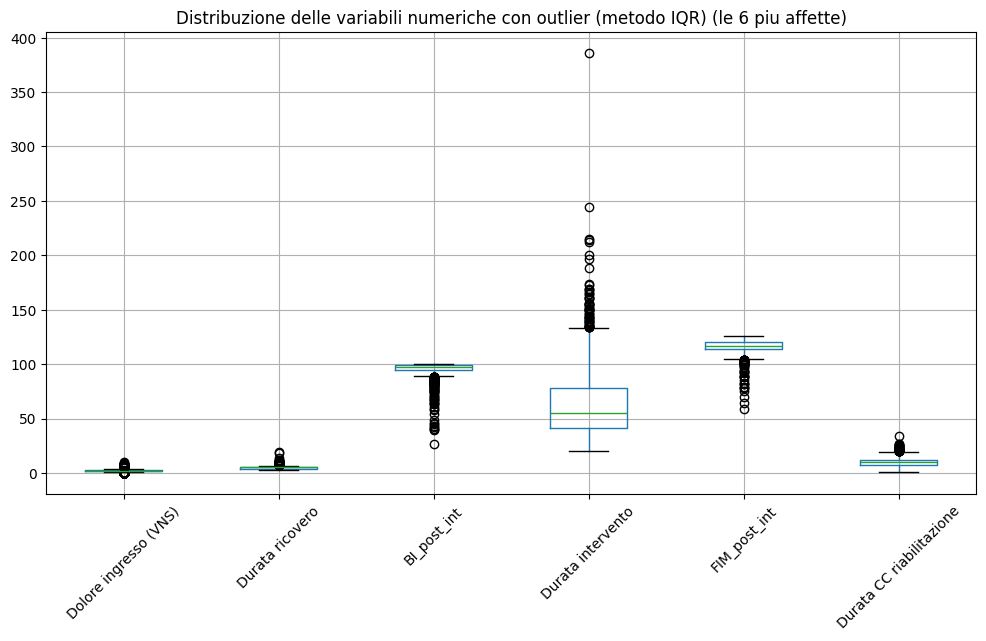

In [318]:
# ============================
# 4. Visualizzazione (Boxplot)
# ============================

# Boxplot per visualizzare le variabili più affette da outlier
cols_to_plot = outlier_report[outlier_report['Percentuale_outlier'] > 0].index[:6]  # le prime 6 più affette

plt.figure(figsize=(12, 6))
df[cols_to_plot].boxplot()
plt.title("Distribuzione delle variabili numeriche con outlier (metodo IQR) (le 6 piu affette)")
plt.xticks(rotation=45)
plt.show()

In [319]:
df_with_outliers = df.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Dataset_with_outliers.csv', index=False)

In [320]:
df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Terapia farmacologica,Farmaci extra,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili
0,715.15,81.51,postero-laterale,79.0,F,Pensionato Che Ha Lavorato,28.0,5.0,2,93.0,...,Sì,No,9.9,12.0,Istituto,Meno di 3h,99.0,119.0,Autonomo,2 canadesi
1,715.16,81.54,pararotuleo,79.0,F,Pensionato Che Ha Lavorato,24.0,6.0,2,95.0,...,In parte,No,9.4,15.0,Istituto,Meno di 3h,84.0,109.0,Autonomo,2 canadesi
2,715.16,81.54,pararotuleo,73.0,F,Pensionato Che Ha Lavorato,26.0,6.0,2,121.0,...,Sì,No,9.0,16.0,Domicilio con parenti,Meno di 3h,100.0,118.0,Autonomo,2 canadesi
3,715.15,81.51,postero-laterale,73.0,F,Pensionato Che Ha Lavorato,23.0,6.0,1,88.0,...,NaN,No,10.1,10.0,Domicilio con parenti,Meno di 3h,84.0,107.0,Con supervisore,2 canadesi
4,715.16,81.54,pararotuleo,81.0,F,Pensionato Che Ha Lavorato,38.0,6.0,2,99.0,...,In parte,No,8.8,20.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,715.15,81.51,anteriore,63.0,M,Pensionato Che Ha Lavorato,26.0,5.0,1,68.0,...,NaN,No,12.1,12.0,Domicilio con parenti,Meno di 3h,99.0,115.0,Autonomo,2 canadesi
1706,715.16,81.54,pararotuleo,60.0,M,Imprenditore - Libero Professionista,26.0,3.0,2,31.0,...,NaN,No,10.6,6.0,Domicilio con parenti,Meno di 3h,95.0,118.0,Autonomo,2 canadesi
1707,715.25,81.51,laterale diretto,79.0,F,Pensionato Che Ha Lavorato,21.0,5.0,2,96.0,...,Sì,No,9.3,13.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
1708,715.16,81.54,pararotuleo,49.0,M,Imprenditore - Libero Professionista,24.0,4.0,2,72.0,...,NaN,No,10.0,5.0,Domicilio con parenti,Meno di 3h,97.0,112.0,Autonomo,2 canadesi


## Missing Values

In [321]:
# ============================
# 1. Analisi dei valori mancanti
# ============================

# Calcolo del numero e della percentuale di missing per ogni colonna
missing_count = df.isnull().sum()
missing_rate = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    'Numero_valori_mancanti': missing_count,
    'Percentuale_valori_mancanti': missing_rate.round(2)
}).sort_values(by='Percentuale_valori_mancanti', ascending=False)

print("--- Report Valori Mancanti ---")
print(missing_report)

--- Report Valori Mancanti ---
                                     Numero_valori_mancanti  \
Condizioni pre-esistenti 9                             1709   
Condizioni pre-esistenti 7                             1709   
Condizioni pre-esistenti 8                             1709   
Condizioni pre-esistenti 6                             1703   
Condizioni pre-esistenti 4                             1676   
Condizioni pre-esistenti 5                             1676   
Condizioni pre-esistenti 3                             1384   
Condizioni pre-esistenti 2                              932   
Terapia farmacologica                                   373   
Condizioni pre-esistenti 1                              370   
Dolore ingresso (VNS)                                    75   
Ausili Deambulazione                                     51   
Rischio bio                                              36   
Durata intervento                                        26   
ADL                     

In [322]:
# ============================
# 2. Identificazione variabili con % missing
# ============================
low_missing = missing_report[missing_report['Percentuale_valori_mancanti'] < 5]
print("\nVariabili con meno del 5% di valori mancanti:")
print(low_missing)




Variabili con meno del 5% di valori mancanti:
                                     Numero_valori_mancanti  \
Dolore ingresso (VNS)                                    75   
Ausili Deambulazione                                     51   
Rischio bio                                              36   
Durata intervento                                        26   
ADL                                                      24   
BI_post_int                                              23   
BMI Pre-Int                                              22   
FIM_post_int                                             21   
L Autonomia passaggi posturali                           20   
Hb ingresso                                              20   
Accesso chirurgico                                       20   
Vive con                                                 20   
FIM                                                      19   
Anestesia                                                19   
Peso Ass

In [323]:
high_missing = missing_report[missing_report['Percentuale_valori_mancanti'] >6]
print("\nVariabili con piu del 10% di valori mancanti:")
print(high_missing)


Variabili con piu del 10% di valori mancanti:
                            Numero_valori_mancanti  \
Condizioni pre-esistenti 9                    1709   
Condizioni pre-esistenti 7                    1709   
Condizioni pre-esistenti 8                    1709   
Condizioni pre-esistenti 6                    1703   
Condizioni pre-esistenti 4                    1676   
Condizioni pre-esistenti 5                    1676   
Condizioni pre-esistenti 3                    1384   
Condizioni pre-esistenti 2                     932   
Terapia farmacologica                          373   
Condizioni pre-esistenti 1                     370   

                            Percentuale_valori_mancanti  
Condizioni pre-esistenti 9                        99.94  
Condizioni pre-esistenti 7                        99.94  
Condizioni pre-esistenti 8                        99.94  
Condizioni pre-esistenti 6                        99.59  
Condizioni pre-esistenti 4                        98.01  
Condizioni

### High Missing

#### Condizioni pre-esistenti 1 -> 9

Sostituisco i "Missing Values" con il valore stringa "Missing" 

In [324]:
cols = [f"Condizioni pre-esistenti {i}" for i in range(1, 10)]
df[cols] = df[cols].fillna("Missing")
df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Terapia farmacologica,Farmaci extra,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili
0,715.15,81.51,postero-laterale,79.0,F,Pensionato Che Ha Lavorato,28.0,5.0,2,93.0,...,Sì,No,9.9,12.0,Istituto,Meno di 3h,99.0,119.0,Autonomo,2 canadesi
1,715.16,81.54,pararotuleo,79.0,F,Pensionato Che Ha Lavorato,24.0,6.0,2,95.0,...,In parte,No,9.4,15.0,Istituto,Meno di 3h,84.0,109.0,Autonomo,2 canadesi
2,715.16,81.54,pararotuleo,73.0,F,Pensionato Che Ha Lavorato,26.0,6.0,2,121.0,...,Sì,No,9.0,16.0,Domicilio con parenti,Meno di 3h,100.0,118.0,Autonomo,2 canadesi
3,715.15,81.51,postero-laterale,73.0,F,Pensionato Che Ha Lavorato,23.0,6.0,1,88.0,...,NaN,No,10.1,10.0,Domicilio con parenti,Meno di 3h,84.0,107.0,Con supervisore,2 canadesi
4,715.16,81.54,pararotuleo,81.0,F,Pensionato Che Ha Lavorato,38.0,6.0,2,99.0,...,In parte,No,8.8,20.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,715.15,81.51,anteriore,63.0,M,Pensionato Che Ha Lavorato,26.0,5.0,1,68.0,...,NaN,No,12.1,12.0,Domicilio con parenti,Meno di 3h,99.0,115.0,Autonomo,2 canadesi
1706,715.16,81.54,pararotuleo,60.0,M,Imprenditore - Libero Professionista,26.0,3.0,2,31.0,...,NaN,No,10.6,6.0,Domicilio con parenti,Meno di 3h,95.0,118.0,Autonomo,2 canadesi
1707,715.25,81.51,laterale diretto,79.0,F,Pensionato Che Ha Lavorato,21.0,5.0,2,96.0,...,Sì,No,9.3,13.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi
1708,715.16,81.54,pararotuleo,49.0,M,Imprenditore - Libero Professionista,24.0,4.0,2,72.0,...,NaN,No,10.0,5.0,Domicilio con parenti,Meno di 3h,97.0,112.0,Autonomo,2 canadesi


In [325]:
# Calcolo del numero e della percentuale di missing per ogni colonna
((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False)

Terapia farmacologica                  21.812865
Dolore ingresso (VNS)                   4.385965
Ausili Deambulazione                    2.982456
Rischio bio                             2.105263
Durata intervento                       1.520468
ADL                                     1.403509
BI_post_int                             1.345029
BMI Pre-Int                             1.286550
FIM_post_int                            1.228070
Hb ingresso                             1.169591
Vive con                                1.169591
L Autonomia passaggi posturali          1.169591
Accesso chirurgico                      1.169591
FIM                                     1.111111
BI                                      1.111111
Peso Assistenziale                      1.111111
Autonomia Deambulazione                 1.111111
Ausili                                  1.111111
Outcome sociale                         1.111111
Durata CC riabilitazione                1.111111
Farmaci extra       

#### Terapia farmacologica

Presenta il 20% circa di missing values. Valutare sia con imputazione (MICE o simili) che senza imputazione

### Low Missing

I low missing < 5% li elimino

In [326]:
# Calcola la percentuale di missing per ogni colonna
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)    

Terapia farmacologica                  21.812865
Dolore ingresso (VNS)                   4.385965
Ausili Deambulazione                    2.982456
Rischio bio                             2.105263
Durata intervento                       1.520468
ADL                                     1.403509
BI_post_int                             1.345029
BMI Pre-Int                             1.286550
FIM_post_int                            1.228070
Hb ingresso                             1.169591
Vive con                                1.169591
L Autonomia passaggi posturali          1.169591
Accesso chirurgico                      1.169591
FIM                                     1.111111
BI                                      1.111111
Peso Assistenziale                      1.111111
Autonomia Deambulazione                 1.111111
Ausili                                  1.111111
Outcome sociale                         1.111111
Durata CC riabilitazione                1.111111
Farmaci extra       

In [327]:
# Seleziona solo le colonne con al massimo 6% di missing
cols_to_dropna = missing_percent[missing_percent <= 5].index.tolist()

print("Colonne con <=5% missing su cui possiamo rimuovere le righe:")
print(cols_to_dropna)

# Rimuove le righe che hanno NaN in queste colonne
df = df.dropna(subset=cols_to_dropna)

Colonne con <=5% missing su cui possiamo rimuovere le righe:
['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)', 'Accesso chirurgico', 'Età', 'Sesso', 'Professione', 'BMI Pre-Int', 'Durata ricovero', 'ASA', 'Durata intervento', 'Anestesia', 'Rischio bio', 'Trasfusione', 'BI', 'FIM', 'ADL', 'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con', 'Dolore ingresso (VNS)', 'Precedente protesi', 'Condizioni pre-esistenti 1', 'Condizioni pre-esistenti 2', 'Condizioni pre-esistenti 3', 'Condizioni pre-esistenti 4', 'Condizioni pre-esistenti 5', 'Condizioni pre-esistenti 6', 'Condizioni pre-esistenti 7', 'Condizioni pre-esistenti 8', 'Condizioni pre-esistenti 9', 'Farmaci extra', 'Hb ingresso', 'Durata CC riabilitazione', 'Outcome sociale', 'Peso Assistenziale', 'BI_post_int', 'FIM_post_int', 'Autonomia Deambulazione', 'Ausili']


In [328]:
((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False)

Terapia farmacologica                  20.737913
Diagnosi alla dimissione (ICD code)     0.000000
Accesso chirurgico                      0.000000
Procedura (ICD code)                    0.000000
Sesso                                   0.000000
Professione                             0.000000
BMI Pre-Int                             0.000000
Età                                     0.000000
Durata ricovero                         0.000000
ASA                                     0.000000
Anestesia                               0.000000
Durata intervento                       0.000000
Trasfusione                             0.000000
BI                                      0.000000
FIM                                     0.000000
Rischio bio                             0.000000
L Autonomia passaggi posturali          0.000000
Ausili Deambulazione                    0.000000
Vive con                                0.000000
Dolore ingresso (VNS)                   0.000000
Precedente protesi  

In [329]:
df.shape

(1572, 40)

## Imbalance analysis


=== Outcome sociale ===
                       Count  Percentage (%)
Outcome sociale                             
Domicilio con parenti   1425       90.648855
Domicilio da solo         94        5.979644
Istituto                  53        3.371501


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3538834161.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')


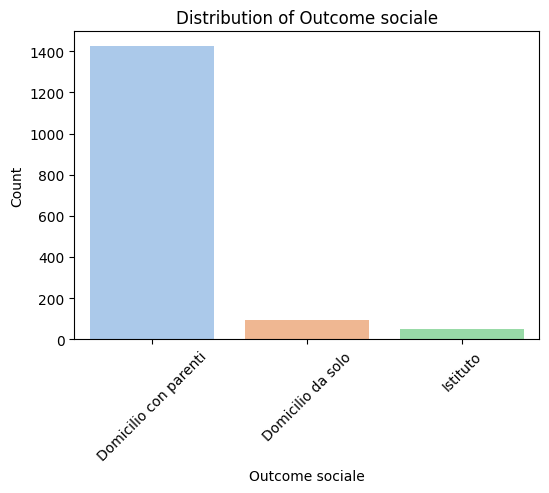


=== Peso Assistenziale ===
                    Count  Percentage (%)
Peso Assistenziale                       
Meno di 3h           1204       76.590331
Nessuno               365       23.218830
Meno di 6h              2        0.127226
Giorno e notte          1        0.063613


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3538834161.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')


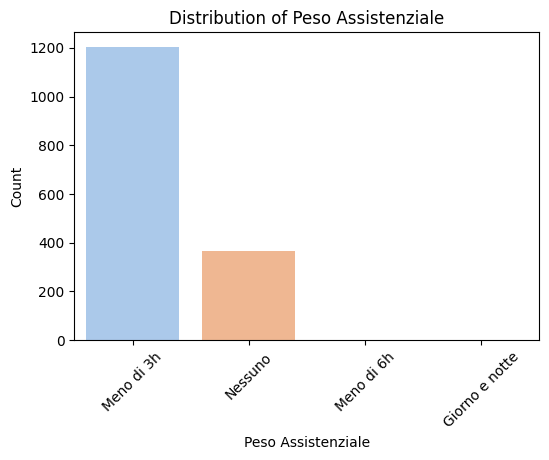


=== Autonomia Deambulazione ===
                         Count  Percentage (%)
Autonomia Deambulazione                       
Autonomo                  1478       94.020356
Autonoma <50m               66        4.198473
Con supervisore             28        1.781170


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3538834161.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')


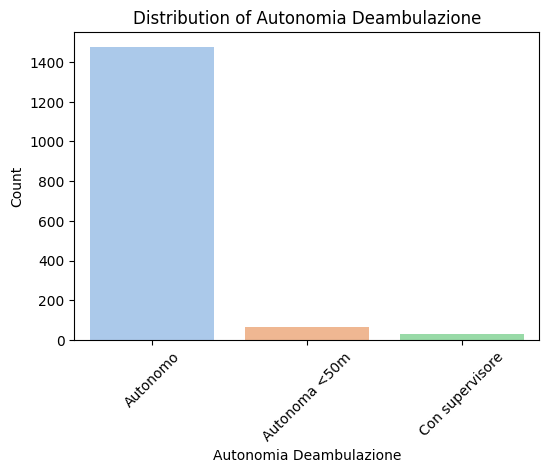


=== Ausili ===
              Count  Percentage (%)
Ausili                             
2 canadesi     1548       98.473282
Deambulatore     20        1.272265
Nessuno           3        0.190840
1 bastone         1        0.063613


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3538834161.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')


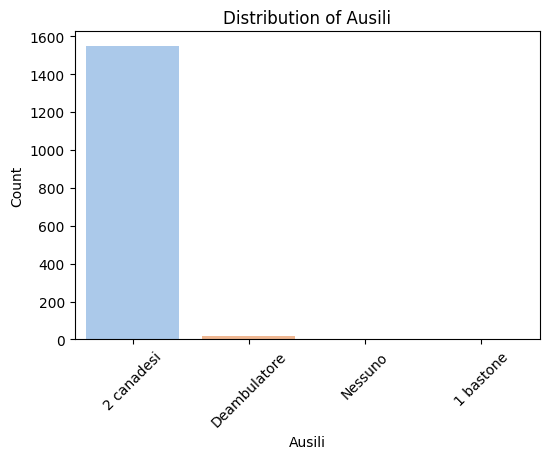


=== Sesso ===
       Count  Percentage (%)
Sesso                       
F        983       62.531807
M        589       37.468193

=== Accesso chirurgico ===
                    Count  Percentage (%)
Accesso chirurgico                       
midvastus             610       38.804071
postero-laterale      522       33.206107
pararotuleo           385       24.491094
anteriore              47        2.989822
laterale diretto        8        0.508906

=== Anestesia ===
               Count  Percentage (%)
Anestesia                           
Subaracnoidea   1498       95.292621
Generale          61        3.880407
Bi-Block          11        0.699746
Blended            2        0.127226

=== Rischio bio ===
             Count  Percentage (%)
Rischio bio                       
No            1547       98.409669
Sì              25        1.590331


In [330]:
# Variabili target categoriali
categorical_targets = [
    'Outcome sociale', 
    'Peso Assistenziale', 
    'Autonomia Deambulazione', 
    'Ausili'
]

# Analisi distribuzioni target
for col in categorical_targets:
    print(f"\n=== {col} ===")
    counts = df[col].value_counts(dropna=False)
    perc = df[col].value_counts(normalize=True, dropna=False) * 100
    imbalance_df = pd.concat([counts, perc], axis=1)
    imbalance_df.columns = ['Count', 'Percentage (%)']
    print(imbalance_df)
    
    # Visualizzazione
    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# Analisi di possibili feature sbilanciate
important_features = ['Sesso', 'Accesso chirurgico', 'Anestesia', 'Rischio bio']
for col in important_features:
    print(f"\n=== {col} ===")
    counts = df[col].value_counts(dropna=False)
    perc = df[col].value_counts(normalize=True, dropna=False) * 100
    imbalance_df = pd.concat([counts, perc], axis=1)
    imbalance_df.columns = ['Count', 'Percentage (%)']
    print(imbalance_df)


In [331]:
df.columns

Index(['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)',
       'Accesso chirurgico', 'Età', 'Sesso', 'Professione', 'BMI Pre-Int',
       'Durata ricovero', 'ASA', 'Durata intervento', 'Anestesia',
       'Rischio bio', 'Trasfusione', 'BI', 'FIM', 'ADL',
       'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con',
       'Dolore ingresso (VNS)', 'Precedente protesi',
       'Condizioni pre-esistenti 1', 'Condizioni pre-esistenti 2',
       'Condizioni pre-esistenti 3', 'Condizioni pre-esistenti 4',
       'Condizioni pre-esistenti 5', 'Condizioni pre-esistenti 6',
       'Condizioni pre-esistenti 7', 'Condizioni pre-esistenti 8',
       'Condizioni pre-esistenti 9', 'Terapia farmacologica', 'Farmaci extra',
       'Hb ingresso', 'Durata CC riabilitazione', 'Outcome sociale',
       'Peso Assistenziale', 'BI_post_int', 'FIM_post_int',
       'Autonomia Deambulazione', 'Ausili'],
      dtype='object')

Accorpo e trasformo in binario le variabili target Outcome Sociale e Peso Assistenziale visto il forte sbilanciamento.


=== Outcome Sociale bin ===
                     Count  Percentage (%)
Outcome Sociale bin                       
0                     1478       94.020356
1                       94        5.979644


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3837096048.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Outcome Sociale bin'] = df['Outcome sociale'].apply(
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3837096048.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Peso Assistenziale bin'] = df['Peso Assistenziale'].apply(
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3837096048.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

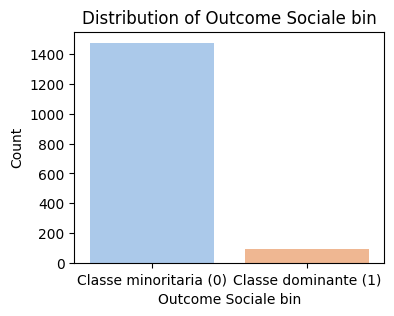


=== Peso Assistenziale bin ===
                        Count  Percentage (%)
Peso Assistenziale bin                       
1                        1204       76.590331
0                         368       23.409669


C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3837096048.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')


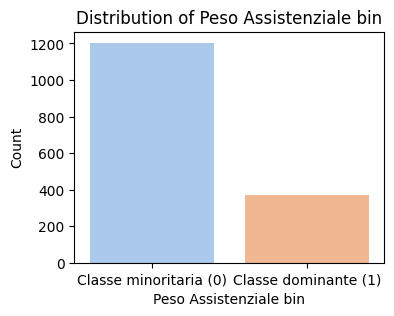

In [ ]:
# Trasformazione variabili target sbilanciate in formato binario

# 1. Outcome sociale: 1 = "Domicilio da solo", 0 = "altro"
df['Outcome Sociale bin'] = df['Outcome sociale'].apply(
    lambda x: 1 if x == 'Domicilio da solo' else 0
)

# 2. Peso Assistenziale:
# 1 = "Meno di 3h" (categoria dominante), 0 = tutte le altre (classi minoritarie)
df['Peso Assistenziale bin'] = df['Peso Assistenziale'].apply(
    lambda x: 1 if x == 'Meno di 3h' else 0
)

# Controllo distribuzioni dopo la trasformazione
for col in ['Outcome Sociale bin', 'Peso Assistenziale bin']:
    print(f"\n=== {col} ===")
    counts = df[col].value_counts()
    perc = df[col].value_counts(normalize=True) * 100
    imbalance_df = pd.concat([counts, perc], axis=1)
    imbalance_df.columns = ['Count', 'Percentage (%)']
    print(imbalance_df)

    # Visualizzazione grafica
    plt.figure(figsize=(4,3))
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Classe minoritaria (0)', 'Classe dominante (1)'])
    plt.show()


## Pre-Processing

In [333]:
df.columns

Index(['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)',
       'Accesso chirurgico', 'Età', 'Sesso', 'Professione', 'BMI Pre-Int',
       'Durata ricovero', 'ASA', 'Durata intervento', 'Anestesia',
       'Rischio bio', 'Trasfusione', 'BI', 'FIM', 'ADL',
       'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con',
       'Dolore ingresso (VNS)', 'Precedente protesi',
       'Condizioni pre-esistenti 1', 'Condizioni pre-esistenti 2',
       'Condizioni pre-esistenti 3', 'Condizioni pre-esistenti 4',
       'Condizioni pre-esistenti 5', 'Condizioni pre-esistenti 6',
       'Condizioni pre-esistenti 7', 'Condizioni pre-esistenti 8',
       'Condizioni pre-esistenti 9', 'Terapia farmacologica', 'Farmaci extra',
       'Hb ingresso', 'Durata CC riabilitazione', 'Outcome sociale',
       'Peso Assistenziale', 'BI_post_int', 'FIM_post_int',
       'Autonomia Deambulazione', 'Ausili', 'Outcome Sociale bin',
       'Peso Assistenziale bin'],
      dtype='object')

Definizione Tragets e Features

In [334]:
features = ['Diagnosi alla dimissione (ICD code)',
       'Procedura (ICD code)', 'Accesso chirurgico', 'Età', 'Sesso',
       'Professione', 'BMI Pre-Int', 'Durata ricovero', 'ASA',
       'Durata intervento', 'Anestesia', 'Rischio bio', 'Trasfusione', 'BI', 'FIM', 'ADL',
       'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con',
       'Dolore ingresso (VNS)', 'Precedente protesi',
       'Condizioni pre-esistenti 1', 'Condizioni pre-esistenti 2',
       'Condizioni pre-esistenti 3', 'Condizioni pre-esistenti 4',
       'Condizioni pre-esistenti 5', 'Condizioni pre-esistenti 6',
       'Condizioni pre-esistenti 7', 'Condizioni pre-esistenti 8',
       'Condizioni pre-esistenti 9', 'Terapia farmacologica', 'Farmaci extra',
       'Hb ingresso']

targets = ['Durata CC riabilitazione', 'Outcome sociale', 'Peso Assistenziale',
       'BI_post_int', 'FIM_post_int', 'Autonomia Deambulazione', 'Ausili']

X = df[features]
y = df[targets]

In [335]:
X.shape, y.shape

((1572, 33), (1572, 7))

In [336]:
df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili,Outcome Sociale bin,Peso Assistenziale bin
1,715.16,81.54,pararotuleo,79.0,F,Pensionato Che Ha Lavorato,24.0,6.0,2,95.0,...,9.4,15.0,Istituto,Meno di 3h,84.0,109.0,Autonomo,2 canadesi,0,1
2,715.16,81.54,pararotuleo,73.0,F,Pensionato Che Ha Lavorato,26.0,6.0,2,121.0,...,9.0,16.0,Domicilio con parenti,Meno di 3h,100.0,118.0,Autonomo,2 canadesi,0,1
3,715.15,81.51,postero-laterale,73.0,F,Pensionato Che Ha Lavorato,23.0,6.0,1,88.0,...,10.1,10.0,Domicilio con parenti,Meno di 3h,84.0,107.0,Con supervisore,2 canadesi,0,1
4,715.16,81.54,pararotuleo,81.0,F,Pensionato Che Ha Lavorato,38.0,6.0,2,99.0,...,8.8,20.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi,0,0
6,715.25,81.51,postero-laterale,74.0,F,Pensionato Che Ha Lavorato,17.0,6.0,3,106.0,...,8.6,18.0,Istituto,Meno di 3h,99.0,115.0,Autonomo,2 canadesi,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,715.15,81.51,anteriore,63.0,M,Pensionato Che Ha Lavorato,26.0,5.0,1,68.0,...,12.1,12.0,Domicilio con parenti,Meno di 3h,99.0,115.0,Autonomo,2 canadesi,0,1
1706,715.16,81.54,pararotuleo,60.0,M,Imprenditore - Libero Professionista,26.0,3.0,2,31.0,...,10.6,6.0,Domicilio con parenti,Meno di 3h,95.0,118.0,Autonomo,2 canadesi,0,1
1707,715.25,81.51,laterale diretto,79.0,F,Pensionato Che Ha Lavorato,21.0,5.0,2,96.0,...,9.3,13.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi,0,0
1708,715.16,81.54,pararotuleo,49.0,M,Imprenditore - Libero Professionista,24.0,4.0,2,72.0,...,10.0,5.0,Domicilio con parenti,Meno di 3h,97.0,112.0,Autonomo,2 canadesi,0,1


In [337]:
df["Professione"].unique()

array(['Pensionato Che Ha Lavorato',
       'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Impiegato, Insegnante',
       'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)',
       'Operaio, Salariato Agricolo, Altro Lavoratore',
       'Disoccupato (Attualmente)', 'Dirigente',
       'Casalinga (Che Ha Svolto Lavoro Retribuito)',
       'Imprenditore - Libero Professionista',
       'Invalido, Inabile (Anche Se Pensionato)',
       'Artigiano, Coltivatore Diretto, Commerciante',
       'Altro (Che Ha Svolto Lavoro Retribuito)', 'Lavorante A Domicilio',
       'Coadiuvante In Aziende A Conduzione Familiare'], dtype=object)

#### CORRELAZIONE VARIABILI NUMERICHE

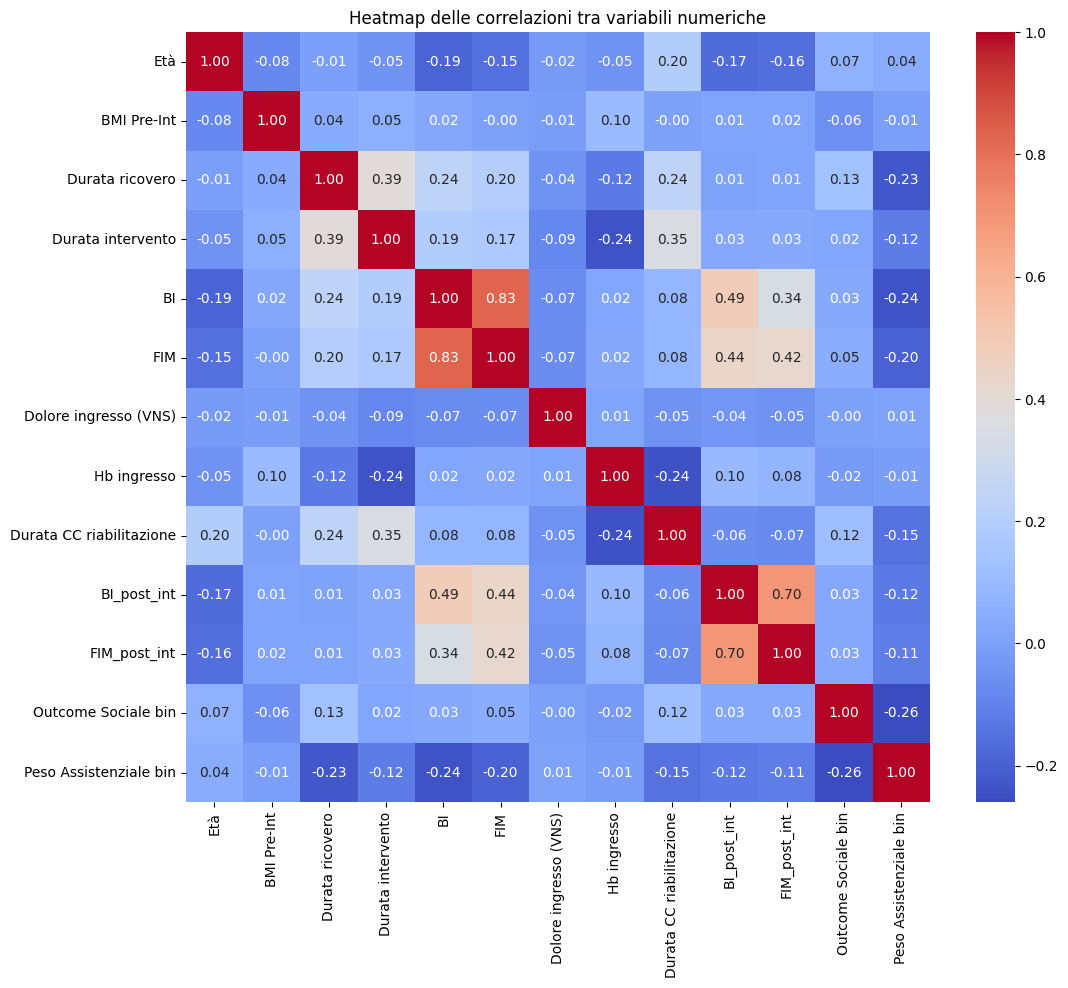

Coppie di variabili numeriche altamente correlate (|corr| > 0.7):
BI e FIM -> correlazione: 0.83


In [338]:
# Selezioniamo solo le colonne numeriche
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_num = df[numerical_cols]

# Calcolo matrice di correlazione
corr_matrix = df_num.corr()

# Heatmap delle correlazioni
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap delle correlazioni tra variabili numeriche")
plt.show()

# Troviamo le coppie di variabili più correlate (escludendo diagonale)
threshold = 0.7  # soglia per definire correlazioni "alte"
high_corr_pairs = []
seen = set()
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j:
            pair = tuple(sorted([i, j]))
            if pair not in seen:
                seen.add(pair)
                corr_val = corr_matrix.loc[i, j]
                if abs(corr_val) > threshold:
                    high_corr_pairs.append((pair[0], pair[1], corr_val))

# Ordiniamo per correlazione decrescente (in valore assoluto)
high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

# Stampiamo le coppie più correlate
print(f"Coppie di variabili numeriche altamente correlate (|corr| > {threshold}):")
for var1, var2, corr_val in high_corr_pairs:
    print(f"{var1} e {var2} -> correlazione: {corr_val:.2f}")

#### Saving Data

In [339]:
# Salviamo il DataFrame in un file CSV
df.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Data_No_PreProcessing.csv', index=False)

#### STEP 0: CREATE FIXED BINARY FEATURES (before split)


In [340]:
# Create binary variables
df['Sesso_F'] = df['Sesso'].map({'M':0, 'F':1})
df['Rischio_bio_bin'] = df['Rischio bio'].map({'No':0, 'Sì':1})
df['Trasfusione_bin'] = df['Trasfusione'].map({'No':0, 'Sì':1})
df['Farmaci_extra_bin'] = df['Farmaci extra'].map({'No':0, 'Sì':1})

# Professione → Sedentarieta
sedentary = ['Pensionato Che Ha Lavorato',
             'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)',
             'Disoccupato (Attualmente)',
             'Invalido, Inabile (Anche Se Pensionato)',
             'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)']

df['Sedentarieta'] = (~df['Professione'].isin(sedentary)).astype(int)

C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\2008755294.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sesso_F'] = df['Sesso'].map({'M':0, 'F':1})
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\2008755294.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rischio_bio_bin'] = df['Rischio bio'].map({'No':0, 'Sì':1})
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\2008755294.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

#### STEP 1: TRAIN/TEST SPLIT


In [341]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Sesso"]) 

I save the data

In [342]:
train_df.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_Data.csv', index=False)
test_df.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_Data.csv', index=False)

In [343]:
train_df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,FIM_post_int,Autonomia Deambulazione,Ausili,Outcome Sociale bin,Peso Assistenziale bin,Sesso_F,Rischio_bio_bin,Trasfusione_bin,Farmaci_extra_bin,Sedentarieta
1557,715.16,81.54,midvastus,83.0,F,Pensionato Che Ha Lavorato,31.0,5.0,2,57.0,...,116.0,Autonomo,2 canadesi,0,0,1,0,0,0,0
1081,715.16,81.54,midvastus,71.0,M,Pensionato Che Ha Lavorato,32.0,5.0,2,52.0,...,120.0,Autonomo,2 canadesi,0,1,0,0,0,0,0
286,715.15,81.51,anteriore,76.0,F,Pensionato Che Ha Lavorato,24.0,5.0,2,54.0,...,123.0,Autonomo,2 canadesi,0,1,1,0,0,0,0
701,715.15,81.51,postero-laterale,65.0,F,Pensionato Che Ha Lavorato,25.0,5.0,2,38.0,...,110.0,Autonomo,2 canadesi,0,0,1,0,0,0,0
939,715.15,81.51,postero-laterale,70.0,M,Pensionato Che Ha Lavorato,27.0,3.0,2,29.0,...,118.0,Autonomo,2 canadesi,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,715.16,81.54,pararotuleo,59.0,M,Imprenditore - Libero Professionista,25.0,4.0,2,50.0,...,116.0,Autonomo,2 canadesi,0,1,0,0,0,0,1
194,715.15,81.51,postero-laterale,62.0,F,Pensionato Che Ha Lavorato,41.0,5.0,2,89.0,...,123.0,Autonomo,2 canadesi,0,1,1,0,0,0,0
1672,715.15,81.51,postero-laterale,69.0,F,Pensionato Che Ha Lavorato,25.0,3.0,2,20.0,...,112.0,Autonomo,2 canadesi,0,1,1,0,0,0,0
339,715.16,81.54,midvastus,69.0,M,Pensionato Che Ha Lavorato,30.0,4.0,2,46.0,...,123.0,Autonomo,2 canadesi,0,0,0,0,0,0,0


#### STEP 2: ONE-HOT ENCODING (fit on train only)

In [344]:
categorical_cols = ['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)', 'Accesso chirurgico', 
                    'Anestesia', 'ADL', 'L Autonomia passaggi posturali',
                    'Ausili Deambulazione', 'Vive con', 'Precedente protesi']

# One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on training set
train_ohe = ohe.fit_transform(train_df[categorical_cols])

# Transform test set
test_ohe = ohe.transform(test_df[categorical_cols])

# Get feature names
ohe_columns = ohe.get_feature_names_out(categorical_cols)

# Convert to DataFrame
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_columns, index=train_df.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_columns, index=test_df.index)

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#### STEP 3: BINARY MATRIX FOR PRE-EXISTING CONDITIONS

In [345]:
# Collect all pre-existing conditions in training set
pre_cols = [f'Condizioni pre-esistenti {i}' for i in range(1,10)]

# Get unique conditions excluding "Missing"
unique_conditions = set(train_df[pre_cols].values.ravel())
unique_conditions.discard('Missing')
# ensure stable ordering
unique_conditions = sorted(unique_conditions)

# Function to create binary matrix
def create_condition_matrix(df, pre_cols, unique_conditions):
    # create zero matrix with one column per unique condition
    df_cond = pd.DataFrame(0, index=df.index, columns=unique_conditions)
    # for each condition, mark rows where any of the pre_cols equals that condition
    for cond in unique_conditions:
        df_cond[cond] = df[pre_cols].eq(cond).any(axis=1).astype(int)
    return df_cond

train_cond_df = create_condition_matrix(train_df, pre_cols, unique_conditions)
test_cond_df = create_condition_matrix(test_df, pre_cols, unique_conditions)

#### STEP 4: IMPUTATION OF 'Terapia farmacologica'

In [346]:
# Map categorical responses to numeric
therapy_map = {'No': 0, 'In parte': 0.5, 'Sì': 1}
train_df['Terapia_farm_num'] = train_df['Terapia farmacologica'].map(therapy_map)
test_df['Terapia_farm_num'] = test_df['Terapia farmacologica'].map(therapy_map)

# Now you can use IterativeImputer or KNNImputer
num_cols = ['Terapia_farm_num']

# MICE imputer
mice_imputer = IterativeImputer(random_state=42)
train_mice = mice_imputer.fit_transform(train_df[num_cols])
test_mice = mice_imputer.transform(test_df[num_cols])

# KNN imputer
knn_imputer = KNNImputer()
train_knn = knn_imputer.fit_transform(train_df[num_cols])
test_knn = knn_imputer.transform(test_df[num_cols])

# Funzione per arrotondare ai valori 0, 0.5, 1
def round_therapy_values(x):
    return np.array([min([0, 0.5, 1], key=lambda y: abs(y - val)) for val in x])

# Applica la funzione sulle colonne imputate
train_mice_rounded = round_therapy_values(train_mice.ravel())
test_mice_rounded = round_therapy_values(test_mice.ravel())

# Converti in DataFrame
train_mice_df = pd.DataFrame(train_mice_rounded, columns=['Terapia_farm_num'], index=train_df.index)
test_mice_df = pd.DataFrame(test_mice_rounded, columns=['Terapia_farm_num'], index=test_df.index)

#### STEP 5: STANDARDIZATION OF NUMERIC FEATURES

In [347]:
numeric_cols = ['Età', 'BMI Pre-Int', 'Durata ricovero',"Durata intervento", "BI", "FIM", "Hb ingresso"]  

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[numeric_cols])
test_scaled = scaler.transform(test_df[numeric_cols])

train_scaled_df = pd.DataFrame(train_scaled, columns=numeric_cols, index=train_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=numeric_cols, index=test_df.index)

#### STEP 6: COMBINE ALL TRANSFORMED FEATURES

In [348]:
# Select fixed binary columns
# note: the column created earlier is 'Sesso_F' (not 'Sesso_bin')
fixed_binary_cols = [ 'Sesso_F', 'Rischio_bio_bin',
                     'Trasfusione_bin', 'Farmaci_extra_bin', 'Sedentarieta']

train_final_imputation = pd.concat([
    train_df[fixed_binary_cols],
    train_ohe_df,
    train_cond_df,
    train_scaled_df,
    train_mice_df
], axis=1)

train_final_no_imputation = pd.concat([
    train_df[fixed_binary_cols],
    train_ohe_df,
    train_cond_df,
    train_scaled_df,
    train_df['Terapia_farm_num']
], axis=1)

test_final_imputation = pd.concat([
    test_df[fixed_binary_cols],
    test_ohe_df,
    test_cond_df,
    test_scaled_df,
    test_mice_df
], axis=1)

test_final_no_imputation = pd.concat([
    test_df[fixed_binary_cols],
    test_ohe_df,
    test_cond_df,
    test_scaled_df,
    test_df['Terapia_farm_num']
], axis=1)


print("Preprocessing complete.")
print("Train shape (with imputation):", train_final_imputation.shape)
print("Train shape (without imputation):", train_final_no_imputation.shape)
print("Test shape (with imputation):", test_final_imputation.shape)
print("Test shape (without imputation):", test_final_no_imputation.shape)

Preprocessing complete.
Train shape (with imputation): (1257, 68)
Train shape (without imputation): (1257, 68)
Test shape (with imputation): (315, 68)
Test shape (without imputation): (315, 68)


I save the data

In [349]:
train_final_imputation_PrePro1 = train_final_imputation.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_imputation.csv', index=False)
train_final_no_imputation_PrePro1 = train_final_no_imputation.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_no_imputation.csv', index=False)
test_final_imputation_PrePro1 = test_final_imputation.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_imputation.csv', index=False)
test_final_no_imputation_PrePro1 = test_final_no_imputation.to_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_no_imputation.csv', index=False)

# Modelling and Validation

#### Imputaion Terapia farmacologica

In [152]:
# Target
y_train = train_df['Durata CC riabilitazione']
y_test = test_df['Durata CC riabilitazione']

# Features
X_train = train_final_imputation  
X_test = test_final_imputation    


##### Correlazione con la target

C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\1702073813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")


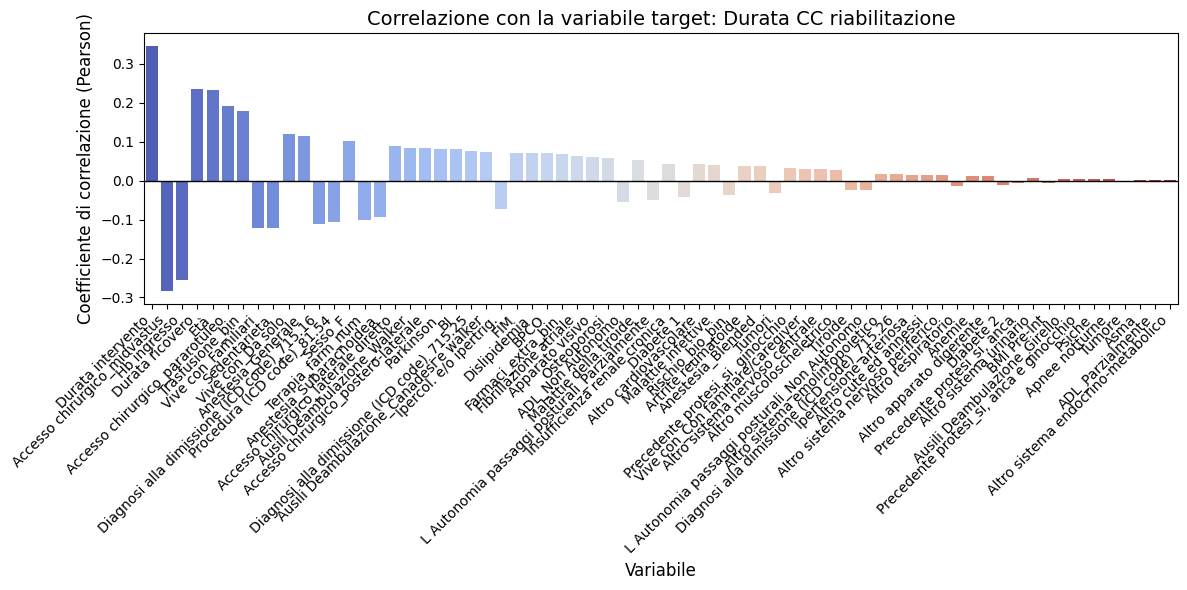

In [153]:

# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Durata CC riabilitazione")], axis=1)

# Calcola correlazione solo con la variabile target
corr_target = df_corr.corr()["Durata CC riabilitazione"].drop("Durata CC riabilitazione")

# Ordina per valore assoluto
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Grafico verticale
plt.figure(figsize=(12, 6))
sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")
plt.axhline(0, color='black', lw=1)
plt.title("Correlazione con la variabile target: Durata CC riabilitazione", fontsize=14)
plt.ylabel("Coefficiente di correlazione (Pearson)", fontsize=12)
plt.xlabel("Variabile", fontsize=12)
plt.xticks(rotation=45, ha='right')  # ruota le etichette per leggerle
plt.tight_layout()
plt.show()

C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\132272407.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


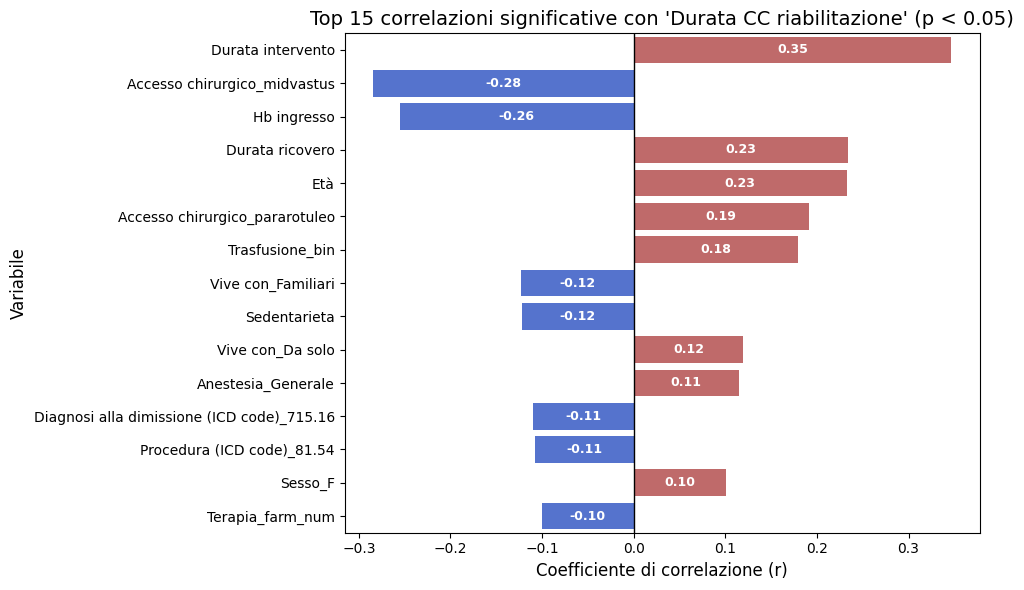

In [154]:
# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Durata CC riabilitazione")], axis=1)
target = "Durata CC riabilitazione"

# Calcola correlazione e p-value
corr_list = []
for col in X_train.columns:
    r, p = pearsonr(df_corr[col], df_corr[target])
    corr_list.append((col, r, p))

corr_df = pd.DataFrame(corr_list, columns=["Variabile", "r", "p_value"])

# Filtra solo correlazioni significative (p < 0.05)
p_cutoff = 0.05
corr_df_sig = corr_df[corr_df["p_value"] < p_cutoff]

# Mostra top N correlazioni per valore assoluto
top_n = 15
corr_df_sig = corr_df_sig.reindex(corr_df_sig["r"].abs().sort_values(ascending=False).head(top_n).index)

# Colori invertiti: rosso = positiva, blu = negativa
colors = ["indianred" if x > 0 else "royalblue" for x in corr_df_sig["r"]]

# Grafico orizzontale
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x="r",
    y="Variabile",
    data=corr_df_sig,
    palette=colors
)
plt.axvline(0, color='black', lw=1)
plt.title(f"Top {top_n} correlazioni significative con '{target}' (p < {p_cutoff})", fontsize=14)
plt.xlabel("Coefficiente di correlazione (r)", fontsize=12)
plt.ylabel("Variabile", fontsize=12)

# Aggiungi valori r dentro le barre
for bar, r_val in zip(bars.patches, corr_df_sig["r"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    x_pos = width / 2
    bars.text(
        x=x_pos,
        y=y_pos,
        s=f"{r_val:.2f}",
        ha='center',
        va='center',
        color='white',  # bianco per contrasto con i colori scuri
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

##### Ridge Reg

In [155]:
# Definizione del modello Ridge

ridge = Ridge(random_state=42)

# Grid dei parametri alpha
param_grid = {
    'alpha': [0, 0.01, 0.1, 1, 10, 100]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# Visualizzare i risultati dettagliati per ogni alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# Modello finale con i migliori parametri
best_ridge = grid_search.best_estimator_

# Predizioni sul test set
y_pred_ridge = best_ridge.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }
# Valutazione finale
evaluate_model_with_ci(y_test, y_pred_ridge, "Ridge Regression (GridSearchCV)")


Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0         0.00    -1.378722e+26    1.479930e+26          0.302107   
1         0.01     1.725175e-01    3.232410e-02          0.303046   
2         0.10     1.765629e-01    3.022204e-02          0.302968   
3         1.00     1.932835e-01    2.243250e-02          0.300770   
4        10.00     2.118271e-01    2.012243e-02          0.288942   
5       100.00     2.258096e-01    2.072551e-02          0.267959   

   std_train_score  
0         0.004459  
1         0.003649  
2         0.003626  
3         0.002991  
4         0.002375  
5         0.004115  

Migliori hyper-parametri: {'alpha': 100}
Miglior punteggio CV (R²): 0.22580958007382496

Ridge Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.43  [2.20, 2.71]
  RMSE       = 3.31  [2.77, 3.92]
  R²         = 0.210  [0.131, 0.288]
  SD(target) = 3.72
  MAE/SD     = 

{'MAE': 2.434706162068941,
 'MAE_CI': array([2.19613352, 2.70850135]),
 'RMSE': np.float64(3.3054527306564103),
 'RMSE_CI': array([2.77053343, 3.92286834]),
 'R2': 0.21046506033618528,
 'R2_CI': array([0.13102987, 0.28801669]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6544873861573859),
 'RMSE/SD': np.float64(0.8885577863390849)}

In [156]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                                        Feature  Coefficient
63                            Durata intervento     0.892850
60                                          Età     0.829178
10                 Accesso chirurgico_midvastus    -0.652711
66                                  Hb ingresso    -0.416705
50                       Ipercol. e/o ipertrig.    -0.366290
..                                          ...          ...
19  L Autonomia passaggi posturali_Parzialmente     0.005236
31                        Altro cute ed annessi    -0.003378
1                               Rischio_bio_bin     0.002467
40                               Apnee notturne    -0.001700
38                       Altro sistema urinario    -0.001317

[68 rows x 2 columns]


In [157]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Durata intervento: 0.893
Età: 0.829
Accesso chirurgico_midvastus: -0.653
Hb ingresso: -0.417
Ipercol. e/o ipertrig.: -0.366


##### Lasso Reg

In [158]:

# ===============================
# 1️⃣ Definizione del modello Lasso
# ===============================
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter alto per garantire convergenza

# Grid dei parametri alpha
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_lasso = grid_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa della tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_lasso, "Lasso Regression (GridSearchCV)")



Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0       0.0001         0.173555        0.031986          0.303030   
1       0.0010         0.185347        0.028152          0.301929   
2       0.0100         0.217582        0.025198          0.281662   
3       0.1000         0.230515        0.026806          0.244921   
4       1.0000         0.042215        0.002842          0.045439   
5      10.0000        -0.001847        0.001925          0.000000   

   std_train_score  
0         0.003648  
1         0.003606  
2         0.003326  
3         0.007038  
4         0.008889  
5         0.000000  

Migliori hyper-parametri: {'alpha': 0.1}
Miglior punteggio CV (R²): 0.23051538885074288

Lasso Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.48  [2.24, 2.77]
  RMSE       = 3.36  [2.81, 3.99]
  R²         = 0.185  [0.104, 0.263]
  SD(target) = 3.72
  MAE/SD     = 

{'MAE': 2.480912570021005,
 'MAE_CI': array([2.23840315, 2.77130041]),
 'RMSE': np.float64(3.3591450561611156),
 'RMSE_CI': array([2.80945625, 3.99092201]),
 'R2': 0.18460701986395356,
 'R2_CI': array([0.10386295, 0.26297403]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6669083968055742),
 'RMSE/SD': np.float64(0.9029911295998685)}

In [159]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                         Feature  Coefficient
10  Accesso chirurgico_midvastus    -0.982210
63             Durata intervento     0.906675
60                           Età     0.805370
66                   Hb ingresso    -0.427711
62               Durata ricovero     0.180589
..                           ...          ...
56                        Psiche     0.000000
55                     Parkinson     0.000000
61                   BMI Pre-Int     0.000000
65                           FIM     0.000000
67              Terapia_farm_num    -0.000000

[68 rows x 2 columns]


In [160]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Accesso chirurgico_midvastus: -0.982
Durata intervento: 0.907
Età: 0.805
Hb ingresso: -0.428
Durata ricovero: 0.181


##### Random Forest

In [161]:
# Definizione del modello base
rf_reg = RandomForestRegressor(random_state=42)

# Definizione del grid dei parametri da testare
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi usare anche 'neg_mean_absolute_error'
    n_jobs=-1
)

# Fit del GridSearch sul train set
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
best_params = grid_search.best_params_
print("Best Hyper-parameters:", best_params)

# Creiamo il modello finale con i migliori parametri
best_rf = grid_search.best_estimator_

# Predizioni sul test set
y_pred_rf = best_rf.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione del modello ottimizzato
evaluate_model_with_ci(y_test, y_pred_rf, "Random Forest Regressor (GridSearchCV)")

Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Random Forest Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.22  [1.95, 2.48]
  RMSE       = 3.25  [2.70, 3.88]
  R²         = 0.237  [0.126, 0.333]
  SD(target) = 3.72
  MAE/SD     = 0.596
  RMSE/SD    = 0.874


{'MAE': 2.216472763987009,
 'MAE_CI': array([1.94827466, 2.4840193 ]),
 'RMSE': np.float64(3.2502486731438403),
 'RMSE_CI': array([2.69997219, 3.87775222]),
 'R2': 0.2366167416861895,
 'R2_CI': array([0.12590189, 0.33310883]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5958228095000062),
 'RMSE/SD': np.float64(0.8737180656904209)}

                                        feature  importance
0                               Durata ricovero    0.236577
1                             Durata intervento    0.184929
2                                           Età    0.167526
3                                   Hb ingresso    0.118329
4                                           FIM    0.050978
5                                            BI    0.048689
6                                   BMI Pre-Int    0.047045
7                              Terapia_farm_num    0.018298
8                               Trasfusione_bin    0.018132
9                  Accesso chirurgico_midvastus    0.008566
10                            Farmaci_extra_bin    0.008241
11                                      Sesso_F    0.007398
12          Accesso chirurgico_postero-laterale    0.007085
13  L Autonomia passaggi posturali_Parzialmente    0.006740
14                       Malattie della tiroide    0.006645


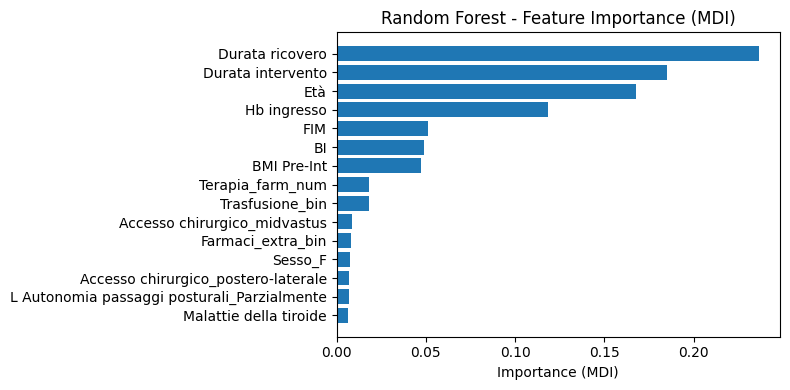

In [162]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_rf è il modello preso da GridSearchCV (come nel tuo codice)
mdi_importances = best_rf.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(15))


# Grafico orizzontale top 15
top_n = 15
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Random Forest - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

In [163]:
# 1. Crea un oggetto explainer specifico per modelli tree-based
explainer = shap.TreeExplainer(best_rf)

# 2. Calcola i valori SHAP (quanto ciascuna feature contribuisce alla predizione per ogni campione)
shap_values = explainer.shap_values(X_test)

# 3. Ottieni anche i valori predetti e la base line (expected value)
expected_value = explainer.expected_value
print(f"Expected value (base prediction): {np.ravel(expected_value)[0]:.3f}")


Expected value (base prediction): 10.230


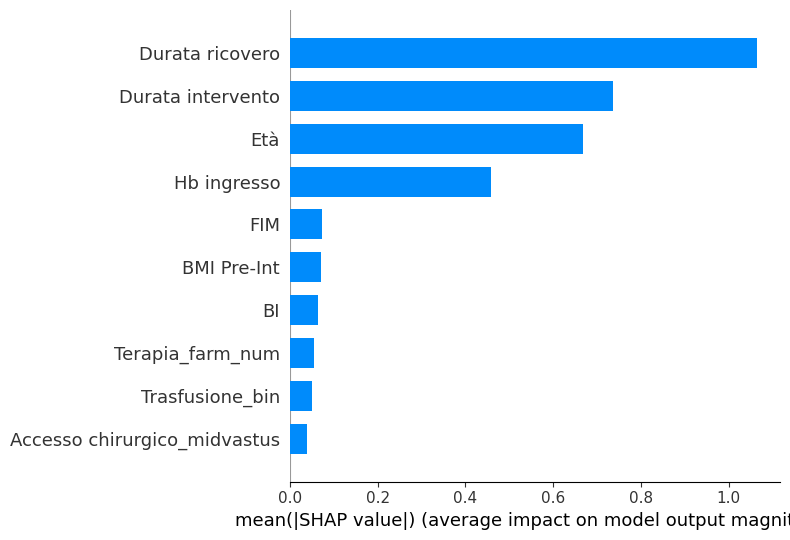

In [164]:
# Calcola l'importanza media assoluta di ogni feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Crea un DataFrame per ordinarle
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Seleziona le prime 10 feature più importanti
top_features = shap_importance['feature'].head(10).tolist()

# Filtra i dati SHAP e X_test sulle prime 10 feature
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]

# Plot con solo le prime 10
shap.summary_plot(shap_values_top, X_test_top, plot_type="bar")

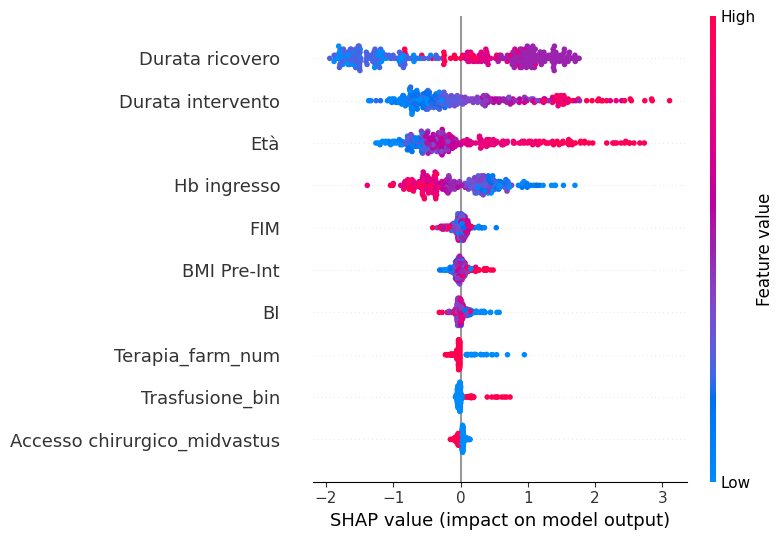

In [165]:
shap.summary_plot(shap_values_top, X_test_top)


##### LightGBM

In [166]:
# ----------------------------
# Pulizia dei nomi delle colonne (fondamentale per LightGBM)
# ----------------------------
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# ----------------------------
# Definizione del modello
# ----------------------------
lgb_reg = lgb.LGBMRegressor(random_state=42)

# ----------------------------
# Grid dei parametri da testare
# ----------------------------
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 5, 10, 20],          # -1 = nessun limite
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20]
}

# ----------------------------
# GridSearchCV con 5-fold CV
# ----------------------------
grid_search = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # mostra l’errore esatto in caso di fallimento
)

# ----------------------------
# Fit sul train set (con gestione errori)
# ----------------------------
try:
    grid_search.fit(X_train, y_train)
except Exception as e:
    print("❌ Errore durante il fit di GridSearchCV:")
    print(e)
    raise

# ----------------------------
# Migliori parametri trovati
# ----------------------------
best_params = grid_search.best_params_
print("\n✅ Best Hyper-parameters LightGBM:", best_params)

# ----------------------------
# Modello finale con i migliori parametri
# ----------------------------
best_lgb = grid_search.best_estimator_

# ----------------------------
# Predizioni sul test set
# ----------------------------
y_pred_lgb = best_lgb.predict(X_test)

# ----------------------------
# Valutazione con bootstrap CI
# ----------------------------
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n📊 {name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ----------------------------
# Valutazione finale LightGBM
# ----------------------------
evaluate_model_with_ci(y_test, y_pred_lgb, "LightGBM Regressor (GridSearchCV)")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 472
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 55
[LightGBM] [Info] Start training from score 10.232299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

{'MAE': 2.2002399245083675,
 'MAE_CI': array([1.93555526, 2.47345905]),
 'RMSE': np.float64(3.2211543472153625),
 'RMSE_CI': array([2.66189198, 3.85703418]),
 'R2': 0.2502222946998536,
 'R2_CI': array([0.14421292, 0.35016503]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5914591664264369),
 'RMSE/SD': np.float64(0.8658970523683207)}

Top 10 features (LightGBM - gain):
                         feature  importance
63             Durata_intervento        1051
60                           Et_        1024
66                   Hb_ingresso         764
65                           FIM         594
62               Durata_ricovero         497
61                   BMI_Pre_Int         430
64                            BI         400
67              Terapia_farm_num         140
2                Trasfusione_bin          98
10  Accesso_chirurgico_midvastus          90


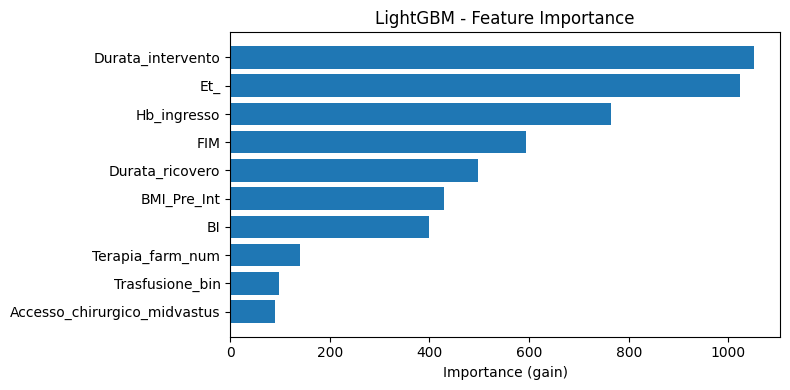

In [167]:
# ----------------------------
# Feature importance basata sul gain
# ----------------------------
gain_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_lgb.feature_importances_  # default è "split", ma puoi usare best_lgb.booster_.feature_importance('gain') per il gain
}).sort_values('importance', ascending=False)

print("Top 10 features (LightGBM - gain):")
print(gain_importance.head(10))

# Grafico
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(gain_importance['feature'].head(top_n)[::-1], gain_importance['importance'].head(top_n)[::-1])
plt.xlabel('Importance (gain)')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()


Top 10 features (SHAP):
                                        feature  mean_abs_shap
62                              Durata_ricovero       0.883606
63                            Durata_intervento       0.755178
60                                          Et_       0.578238
66                                  Hb_ingresso       0.395081
10                 Accesso_chirurgico_midvastus       0.107307
65                                          FIM       0.094644
2                               Trasfusione_bin       0.081628
61                                  BMI_Pre_Int       0.065061
67                             Terapia_farm_num       0.063459
19  L_Autonomia_passaggi_posturali_Parzialmente       0.058867


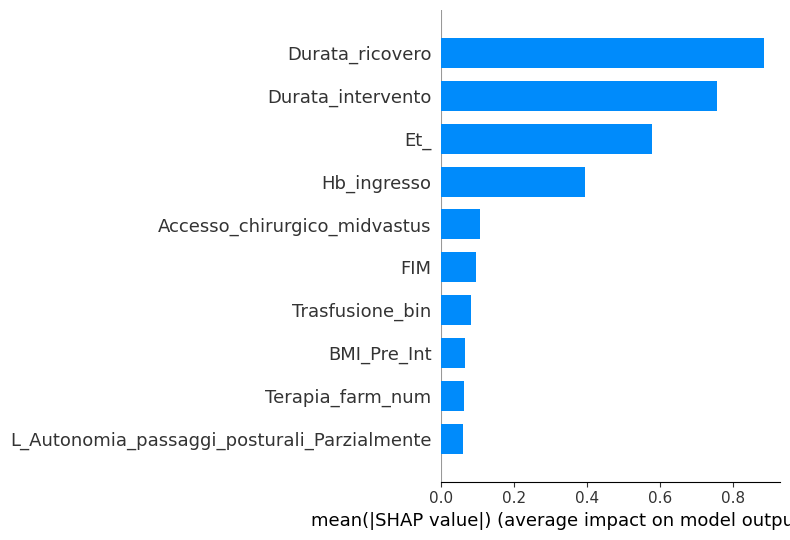

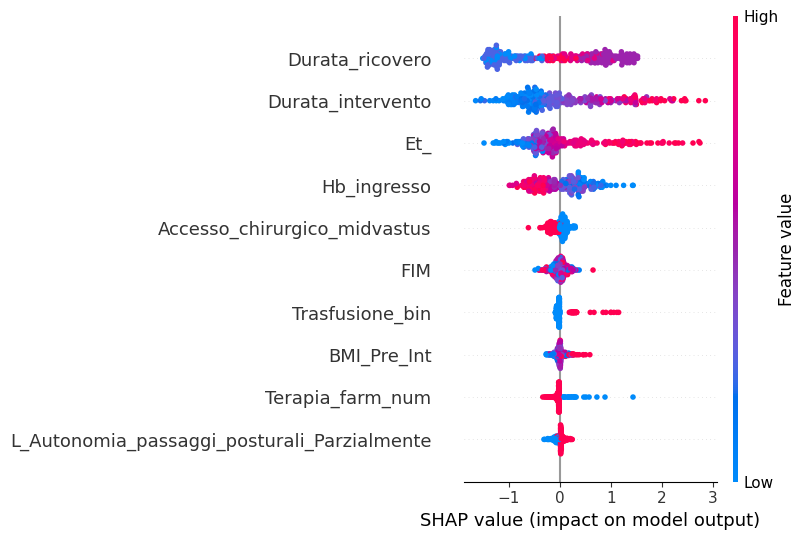

In [168]:

# 1️⃣ Crea l’explainer
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)

# 2️⃣ Importanza globale media assoluta
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

print("Top 10 features (SHAP):")
print(shap_importance.head(10))

# 3️⃣ Grafico top 10
top_features = shap_importance['feature'].head(10).tolist()
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]

shap.summary_plot(shap_values_top, X_test_top, plot_type="bar")
shap.summary_plot(shap_values_top, X_test_top)  # valori SHAP per singolo sample


##### Decision Tree

In [169]:
# ===============================
# 1️⃣ Definizione del modello Decision Tree
# ===============================
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid dei parametri da testare
param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi cambiare in 'neg_mean_absolute_error' se preferisci
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di iperparametri:")
print(cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
                  'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_dt, "Decision Tree Regressor (GridSearchCV)")


Risultati della cross-validation per ogni combinazione di iperparametri:
   param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0             None                        2                       1   
1             None                        5                       1   
2             None                       10                       1   
3             None                        2                       2   
4             None                        5                       2   
5             None                       10                       2   
6             None                        2                       4   
7             None                        5                       4   
8             None                       10                       4   
9                5                        2                       1   
10               5                        5                       1   
11               5                       10                       1   
12 

{'MAE': 2.31609302284508,
 'MAE_CI': array([2.03316102, 2.6111852 ]),
 'RMSE': np.float64(3.467206439480452),
 'RMSE_CI': array([2.90490793, 4.10235617]),
 'R2': 0.13130193716935679,
 'R2_CI': array([-0.02507484,  0.25266697]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6226023050482229),
 'RMSE/SD': np.float64(0.9320397324313182)}

                               feature  importance
0                      Durata_ricovero    0.364085
1                                  Et_    0.164969
2                    Durata_intervento    0.161444
3                          Hb_ingresso    0.117810
4                                  FIM    0.051387
5                          BMI_Pre_Int    0.044702
6                                   BI    0.028301
7                     Terapia_farm_num    0.026639
8  Accesso_chirurgico_postero_laterale    0.017233
9                   Malattie_infettive    0.011924


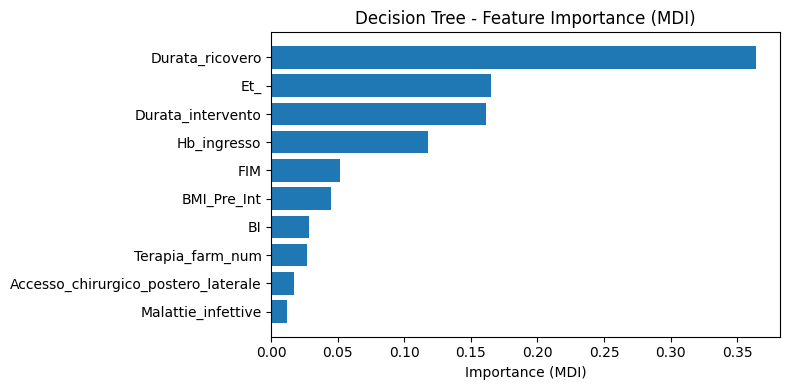

In [170]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_dt è il modello preso da GridSearchCV 
mdi_importances = best_dt.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(10))


# Grafico orizzontale top 15
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Decision Tree - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

In [171]:
# 1. Crea un oggetto explainer specifico per modelli tree-based
explainer = shap.TreeExplainer(best_dt)

# 2. Calcola i valori SHAP (quanto ciascuna feature contribuisce alla predizione per ogni campione)
shap_values = explainer.shap_values(X_test)

# 3. Ottieni anche i valori predetti e la base line (expected value)
expected_value = explainer.expected_value
print(f"Expected value (base prediction): {np.ravel(expected_value)[0]:.3f}")


Expected value (base prediction): 10.232


Top 10 features (SHAP):
                                feature  mean_abs_shap
62                      Durata_ricovero       1.191000
60                                  Et_       0.789962
63                    Durata_intervento       0.724559
66                          Hb_ingresso       0.394221
65                                  FIM       0.146107
61                          BMI_Pre_Int       0.124655
67                     Terapia_farm_num       0.058789
12  Accesso_chirurgico_postero_laterale       0.050438
64                                   BI       0.028815
53                   Malattie_infettive       0.014752


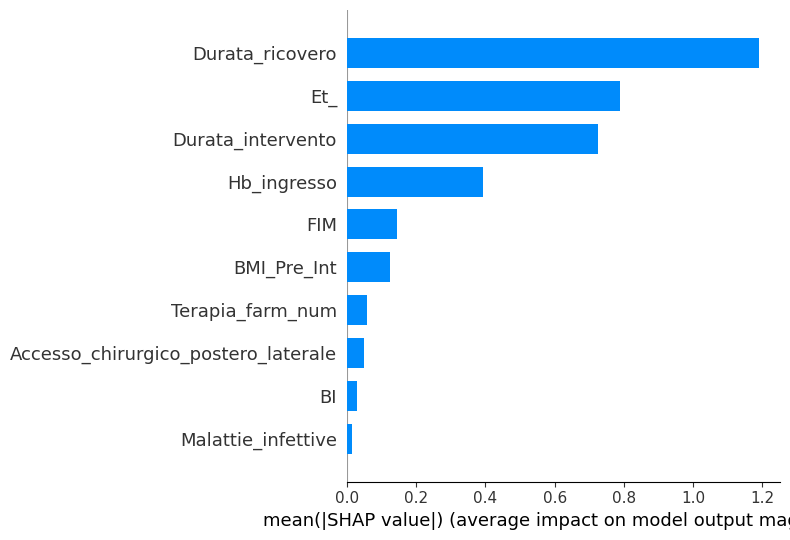

In [172]:
# Calcola l'importanza media assoluta di ogni feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Crea un DataFrame per ordinarle
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Seleziona le prime 10 feature più importanti
top_features = shap_importance['feature'].head(10).tolist()

# Filtra i dati SHAP e X_test sulle prime 10 feature
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]
print("Top 10 features (SHAP):")
print(shap_importance.head(10))
# Plot con solo le prime 10
shap.summary_plot(shap_values_top, X_test_top, plot_type="bar")

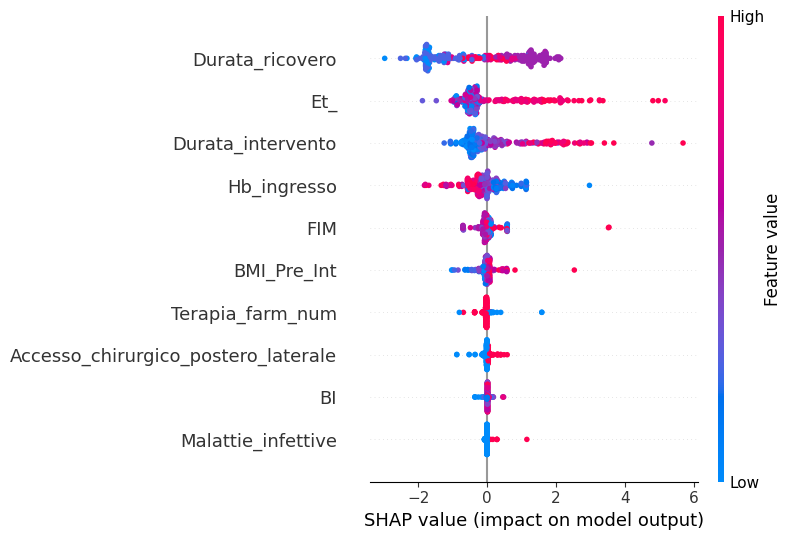

In [173]:
shap.summary_plot(shap_values_top, X_test_top)

##### SVM (SVR)

In [174]:


# ===============================
# 1️⃣ Definizione del modello SVR
# ===============================
svr = SVR()

# Grid dei parametri da testare
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'degree': [2, 3, 4]  # utile solo per kernel='poly'
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search_svr.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results_svr = pd.DataFrame(grid_search_svr.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di parametri:")
print(cv_results_svr[['param_kernel', 'param_C', 'param_epsilon', 'param_degree',
                      'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params_svr = grid_search_svr.best_params_
print("\nMigliori hyper-parametri:", best_params_svr)
print("Miglior punteggio CV (R²):", grid_search_svr.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione con CI (stessa che usi per RF e Lasso)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_svr, "Support Vector Regressor (GridSearchCV)")



Risultati della cross-validation per ogni combinazione di parametri:
    param_kernel  param_C  param_epsilon  param_degree  mean_test_score  \
0         linear      0.1           0.01             2         0.197647   
1           poly      0.1           0.01             2         0.224767   
2            rbf      0.1           0.01             2         0.211646   
3        sigmoid      0.1           0.01             2         0.182639   
4         linear      0.1           0.10             2         0.200046   
..           ...      ...            ...           ...              ...   
187      sigmoid    100.0           0.50             4    -15810.965298   
188       linear    100.0           1.00             4         0.177988   
189         poly    100.0           1.00             4        -1.353241   
190          rbf    100.0           1.00             4         0.047182   
191      sigmoid    100.0           1.00             4    -16084.618321   

     std_test_score  mean_tra

{'MAE': 2.2578990301406363,
 'MAE_CI': array([2.02129405, 2.51330553]),
 'RMSE': np.float64(3.1894486382533933),
 'RMSE_CI': array([2.6457873 , 3.79966888]),
 'R2': 0.2649097244410952,
 'R2_CI': array([0.18721548, 0.34581864]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6069588427000486),
 'RMSE/SD': np.float64(0.8573740581326826)}

Top 10 Feature Importance (Permutation):
Durata_intervento: 0.1142
Durata_ricovero: 0.0847
Et_: 0.0324
Accesso_chirurgico_midvastus: 0.0214
Hb_ingresso: 0.0123
BI: 0.0094
FIM: 0.0065
Accesso_chirurgico_pararotuleo: 0.0046
ADL_Non_Autonomo: 0.0040
Procedura_ICD_code__81_54: 0.0029


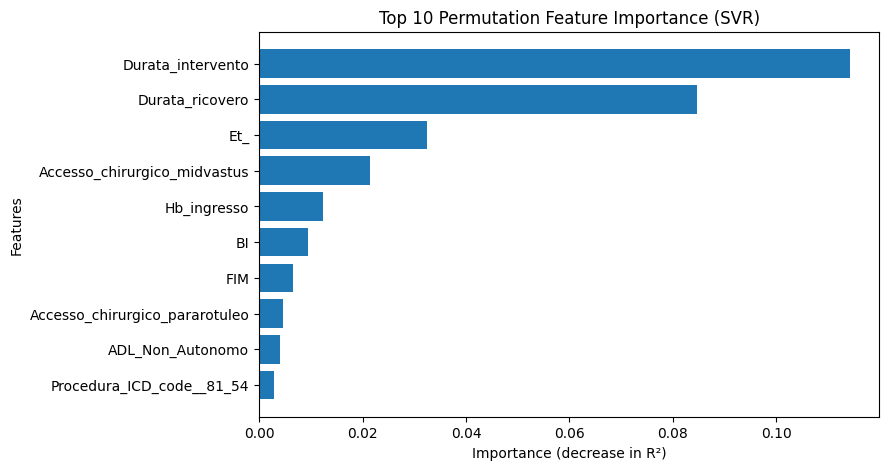

In [175]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_svr, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (SVR)")
plt.show()


##### MLP

In [176]:
# =======================================
# 1️⃣ Import librerie aggiornate
# =======================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasRegressor  # ✅ sostituisce il vecchio wrapper
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# 2️⃣ Funzione per costruire il modello
# =======================================
def build_model(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# =======================================
# 3️⃣ Wrapping con scikeras
# =======================================
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)

# =======================================
# 4️⃣ Ricerca iperparametri
# =======================================
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [32, 64, 128],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ["adam", "rmsprop"],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100]
}

random_search = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# =======================================
# 5️⃣ Training
# =======================================
random_search.fit(X_train, y_train)

# Migliori parametri
print("\nBest Hyper-parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# =======================================
# 6️⃣ Predizioni
# =======================================
y_pred_dl = best_model.predict(X_test)

# =======================================
# 7️⃣ Valutazione (uguale alla tua)
# =======================================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

# =======================================
# 8️⃣ Valutazione finale
# =======================================
evaluate_model_with_ci(y_test, y_pred_dl, "Deep Learning Regressor (Keras MLP)")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyper-parameters: {'model__optimizer': 'rmsprop', 'model__n_neurons': 128, 'model__n_hidden': 1, 'model__lr': 0.0005, 'model__dropout_rate': 0.3, 'epochs': 100, 'batch_size': 64}

Deep Learning Regressor (Keras MLP) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.28  [2.04, 2.53]
  RMSE       = 3.17  [2.69, 3.70]
  R²         = 0.274  [0.165, 0.358]
  SD(target) = 3.72
  MAE/SD     = 0.613
  RMSE/SD    = 0.852


Top 10 Feature Importance (Permutation):
Accesso_chirurgico_postero_laterale: 0.1736
Durata_intervento: 0.1464
Vive_con_Da_solo: 0.1304
Durata_ricovero: 0.1023
Vive_con_Familiari: 0.0879
Et_: 0.0444
Anestesia_Subaracnoidea: 0.0394
Anestesia_Generale: 0.0331
FIM: 0.0280
Malattie_infettive: 0.0269


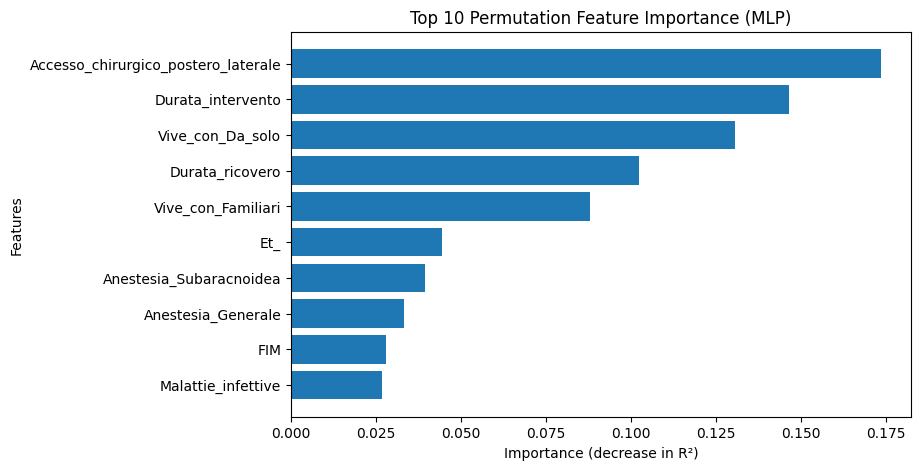

In [177]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (MLP)")
plt.show()


##### Test tra modelli

In [178]:


def compare_models(y_test, y_pred_model1, y_pred_model2):
    # Calcola i residui assoluti
    residuals1 = np.abs(y_test - y_pred_model1)
    residuals2 = np.abs(y_test - y_pred_model2)
    
    # Wilcoxon signed-rank test (non parametrico)
    stat, p_value = wilcoxon(residuals1, residuals2)
    return stat, p_value

def compare_multiple_models(y_test, predictions_dict, correction='fdr_bh'):
    """
    Confronta tutti i modelli a coppie usando il test di Wilcoxon
    e corregge i p-value per ipotesi multiple.
    """
    results = []
    p_values = []
    pairs = []
    
    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):
        stat, p_value = compare_models(y_test, y_pred1, y_pred2)
        results.append({
            'Model 1': name1,
            'Model 2': name2,
            'Statistic': stat,
            'Raw p-value': p_value
        })
        p_values.append(p_value)
        pairs.append((name1, name2))
    
    # Correzione per test multipli (default: Benjamini–Hochberg FDR)
    reject, corrected_pvals, _, _ = multipletests(p_values, method=correction)
    
    for i, res in enumerate(results):
        res['Corrected p-value'] = corrected_pvals[i]
        res['Significant'] = reject[i]
    
    return pd.DataFrame(results)

# Esempio d’uso:
predictions = {
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'RandomForest': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'Decision Tree': y_pred_dt,
    'SVM (SVR)': y_pred_svr,
    'MLP': y_pred_dl.flatten()
}

results_df = compare_multiple_models(y_test, predictions)
print(results_df)


          Model 1        Model 2  Statistic  Raw p-value  Corrected p-value  \
0           Ridge          Lasso    21219.0     0.023444           0.044756   
1           Ridge   RandomForest    18691.0     0.000129           0.000451   
2           Ridge       LightGBM    18389.0     0.000059           0.000249   
3           Ridge  Decision Tree    20823.0     0.012042           0.025288   
4           Ridge      SVM (SVR)    18120.0     0.000029           0.000152   
5           Ridge            MLP    19637.0     0.001178           0.003094   
6           Lasso   RandomForest    18057.0     0.000024           0.000152   
7           Lasso       LightGBM    17641.0     0.000008           0.000079   
8           Lasso  Decision Tree    20339.0     0.004953           0.011556   
9           Lasso      SVM (SVR)    17457.0     0.000004           0.000079   
10          Lasso            MLP    19233.0     0.000476           0.001429   
11   RandomForest       LightGBM    24615.0     0.86

##### Errori rilevanti

In [179]:

# Calcolo degli errori assoluti
errors_ridge = np.abs(y_test - y_pred_ridge)
errors_lasso = np.abs(y_test - y_pred_lasso)
errors_rf = np.abs(y_test - y_pred_rf)
errors_lgb = np.abs(y_test - y_pred_lgb)
errors_dt = np.abs(y_test - y_pred_dt)
errors_svr = np.abs(y_test - y_pred_svr)
errors_mlp = np.abs(y_test - y_pred_dl.flatten())


# Threshold: > 2x MAE
threshold_ridge = 2 * np.mean(errors_ridge)
threshold_lasso = 2 * np.mean(errors_lasso)
threshold_rf = 2 * np.mean(errors_rf)
threshold_lgb = 2 * np.mean(errors_lgb)
threshold_dt = 2 * np.mean(errors_dt)
threshold_svr = 2 * np.mean(errors_svr)
threshold_mlp = 2 * np.mean(errors_mlp)

# Casi rilevanti
outliers_ridge = y_test[errors_ridge > threshold_ridge]
outliers_lasso = y_test[errors_lasso > threshold_lasso]
outliers_rf = y_test[errors_rf > threshold_rf]
outliers_lgb = y_test[errors_lgb > threshold_lgb]
outliers_dt = y_test[errors_lgb > threshold_dt]
outliers_svr = y_test[errors_lgb > threshold_svr]
outliers_mlp = y_test[errors_lgb > threshold_mlp]

print("Ridge Regression - Outliers (>2x MAE):")
print(outliers_ridge)

print("\nLasso Regression - Outliers (>2x MAE):")
print(outliers_lasso)

print("\nRandom Forest - Outliers (>2x MAE):")
print(outliers_rf)

print("\nLightGBM - Outliers (>2x MAE):")
print(outliers_lgb)

print("\Decision Tree - Outliers (>2x MAE):")
print(outliers_dt)

print("\SVM (SVR) - Outliers (>2x MAE):")
print(outliers_svr)

print("\MLP - Outliers (>2x MAE):")
print(outliers_mlp)

Ridge Regression - Outliers (>2x MAE):
1609    18.0
115      7.0
1576    17.0
926     19.0
270     20.0
874      8.0
1359    34.0
6       18.0
49      26.0
1613     6.0
144      7.0
66       3.0
1400    15.0
50      23.0
7       22.0
30      25.0
17      20.0
94      20.0
622      6.0
Name: Durata CC riabilitazione, dtype: float64

Lasso Regression - Outliers (>2x MAE):
1609    18.0
115      7.0
1576    17.0
926     19.0
655     14.0
270     20.0
1359    34.0
6       18.0
49      26.0
144      7.0
66       3.0
1400    15.0
923      9.0
50      23.0
1479    17.0
7       22.0
30      25.0
17      20.0
94      20.0
622      6.0
Name: Durata CC riabilitazione, dtype: float64

Random Forest - Outliers (>2x MAE):
1609    18.0
405      8.0
115      7.0
1576    17.0
215      7.0
869      7.0
926     19.0
1295     6.0
270     20.0
1359    34.0
1648    14.0
666     16.0
735      4.0
6       18.0
49      26.0
366      8.0
1613     6.0
1246     6.0
1448     7.0
657     11.0
1544     6.0
144      7

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3476961255.py:41: SyntaxWarning: invalid escape sequence '\D'
  print("\Decision Tree - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3476961255.py:44: SyntaxWarning: invalid escape sequence '\S'
  print("\SVM (SVR) - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\3476961255.py:47: SyntaxWarning: invalid escape sequence '\M'
  print("\MLP - Outliers (>2x MAE):")


##### Taylor

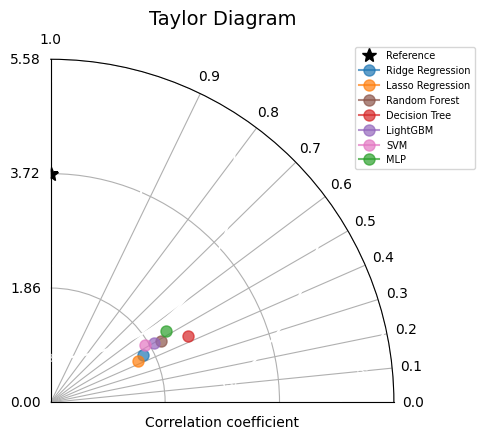

In [180]:
import numpy as np
import matplotlib.pyplot as plt

class TaylorDiagram:
    def __init__(self, refstd, fig=None, rect=111, label='Reference', srange=(0, 1.5)):
        self.refstd = refstd
        self.fig = fig or plt.figure(figsize=(12, 10))  # figura più grande
        self.ax = self.fig.add_subplot(rect, polar=True)
        
        self.ax.set_theta_direction(-1)
        self.ax.set_theta_zero_location("N")
        self.ax.set_xlim(0, np.pi / 2)
        self.ax.set_ylim(0, srange[1] * refstd)

        corr_ticks = np.linspace(1, 0, 11)
        self.ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[f"{c:.1f}" for c in corr_ticks])
        self.ax.set_rgrids(np.linspace(0, srange[1]*refstd, 4), angle=135)
        self.ax.set_xlabel("Correlation coefficient")

        self.ax.plot(0, refstd, 'k*', markersize=10, label=label)

    def add_sample(self, stddev, corrcoef, label, marker='o', color=None):
        corrcoef = np.clip(corrcoef, -1, 1)  # Evita errori numerici
        theta = np.arccos(corrcoef)
        self.ax.plot(theta, stddev, marker=marker, color=color, label=label, markersize=8)

    def add_contours(self, levels=5, **kwargs):
        rs = np.linspace(0, 1.5 * self.refstd, 100)
        ts = np.linspace(0, np.pi / 2, 100)
        rs, ts = np.meshgrid(rs, ts, indexing='xy')
        rms = np.sqrt(self.refstd**2 + rs**2 - 2 * self.refstd * rs * np.cos(ts))
        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)
        self.ax.clabel(contours, inline=1, fontsize=8, fmt='%.2f')

    def show(self):
        self.ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=7, markerscale=1)
        plt.title("Taylor Diagram", fontsize=14)
        plt.tight_layout(pad=2.0)
        plt.show()



models = {
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Random Forest": y_pred_rf,
    'Decision Tree': y_pred_dt,
    "LightGBM": y_pred_lgb,
    "SVM": y_pred_svr,
    "MLP": y_pred_dl.flatten()
}

import numpy as np
import matplotlib.colors as mcolors

# Calcolo deviazione standard e correlazione
refstd = np.std(y_test)
taylor = TaylorDiagram(refstd)

colors = ['tab:blue', 'tab:orange', 'tab:brown', 'tab:red',
          'tab:purple', 'tab:pink', 'tab:green']

# Colori con trasparenza (alpha=0.6)
rgba_colors = [mcolors.to_rgba(c, alpha=0.7) for c in colors]

for (name, y_pred), color in zip(models.items(), rgba_colors):
    stddev = np.std(y_pred)
    corrcoef = np.corrcoef(y_test, y_pred)[0, 1]
    taylor.add_sample(stddev, corrcoef, label=name, color=color, marker='o')

# Contorni grigi più leggeri (senza modificare alpha)
taylor.add_contours(levels=5, colors='1')  # colori più chiari = effetto visivo "sfumato"

taylor.show()





#### No imputation Terapia farmacologica

In [181]:
# Target
y_train = train_df['Durata CC riabilitazione']
y_test = test_df['Durata CC riabilitazione']

# Features
X_train = train_final_no_imputation  
X_test = test_final_no_imputation    

In [182]:
# Per i modelli che non accettano NaN
X_train_drop = X_train.dropna()
y_train_drop = y_train[X_train_drop.index]

X_test_drop = X_test.dropna()
y_test_drop = y_test[X_test_drop.index]

##### LinearReg

In [183]:
# Definizione del modello Ridge
ridge = Ridge(random_state=42)

# Grid dei parametri alpha
param_grid = {
    'alpha': [0, 0.01, 0.1, 1, 10, 100]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train_drop, y_train_drop)

# Visualizzare i risultati dettagliati per ogni alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# Modello finale con i migliori parametri
best_ridge = grid_search.best_estimator_

# Predizioni sul test set
y_pred_ridge = best_ridge.predict(X_test_drop)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione finale
evaluate_model_with_ci(y_test_drop, y_pred_ridge, "Ridge Regression (GridSearchCV)")


Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0         0.00    -6.588964e+26    7.869621e+26          0.322204   
1         0.01     1.623913e-01    4.794206e-02          0.325371   
2         0.10     1.666352e-01    4.587843e-02          0.325149   
3         1.00     1.836913e-01    3.803392e-02          0.320326   
4        10.00     2.032211e-01    3.239943e-02          0.299727   
5       100.00     2.174198e-01    2.691567e-02          0.267510   

   std_train_score  
0         0.008737  
1         0.006468  
2         0.006488  
3         0.006750  
4         0.007202  
5         0.006999  

Migliori hyper-parametri: {'alpha': 100}
Miglior punteggio CV (R²): 0.21741984110326054

Ridge Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.57  [2.29, 2.90]
  RMSE       = 3.57  [2.96, 4.31]
  R²         = 0.197  [0.125, 0.277]
  SD(target) = 3.98
  MAE/SD     = 

{'MAE': 2.573278216396546,
 'MAE_CI': array([2.2875021 , 2.90429335]),
 'RMSE': np.float64(3.567652033675569),
 'RMSE_CI': array([2.96012731, 4.31034922]),
 'R2': 0.19720492907659493,
 'R2_CI': array([0.12459291, 0.27654213]),
 'SD_target': np.float64(3.9818064042202557),
 'MAE/SD': np.float64(0.6462589978430815),
 'RMSE/SD': np.float64(0.8959883207516742)}

In [184]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train_drop.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                           Feature  Coefficient
60                             Età     0.864717
63               Durata intervento     0.860812
10    Accesso chirurgico_midvastus    -0.655746
66                     Hb ingresso    -0.405591
11  Accesso chirurgico_pararotuleo     0.333980
..                             ...          ...
51          Ipertensione arteriosa     0.013711
1                  Rischio_bio_bin     0.011981
34  Altro sistema emolinfopoietico     0.007955
31           Altro cute ed annessi    -0.003307
38          Altro sistema urinario    -0.002690

[68 rows x 2 columns]


In [185]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Età: 0.865
Durata intervento: 0.861
Accesso chirurgico_midvastus: -0.656
Hb ingresso: -0.406
Accesso chirurgico_pararotuleo: 0.334


##### Lasso

In [186]:

# ===============================
# 1️⃣ Definizione del modello Lasso
# ===============================
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter alto per garantire convergenza

# Grid dei parametri alpha
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train_drop, y_train_drop)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_lasso = grid_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_drop)

# ===============================
# 5️⃣ Funzione di valutazione (stessa della tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test_drop, y_pred_lasso, "Lasso Regression (GridSearchCV)")



Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0       0.0001         0.163037        0.047614          0.325359   
1       0.0010         0.170881        0.043535          0.324097   
2       0.0100         0.204810        0.034360          0.299225   
3       0.1000         0.225243        0.035843          0.242227   
4       1.0000         0.026535        0.002953          0.031312   
5      10.0000        -0.003219        0.003539          0.000000   

   std_train_score  
0         0.006468  
1         0.006560  
2         0.007391  
3         0.009726  
4         0.007934  
5         0.000000  

Migliori hyper-parametri: {'alpha': 0.1}
Miglior punteggio CV (R²): 0.2252430141838698

Lasso Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.63  [2.35, 2.97]
  RMSE       = 3.64  [3.02, 4.38]
  R²         = 0.165  [0.089, 0.243]
  SD(target) = 3.98
  MAE/SD     = 0

{'MAE': 2.6321549197512937,
 'MAE_CI': array([2.35169698, 2.97271767]),
 'RMSE': np.float64(3.6374698689175102),
 'RMSE_CI': array([3.01955173, 4.38465721]),
 'R2': 0.16547658325281334,
 'R2_CI': array([0.08928114, 0.24346164]),
 'SD_target': np.float64(3.9818064042202557),
 'MAE/SD': np.float64(0.6610454282663047),
 'RMSE/SD': np.float64(0.9135225321507875)}

In [187]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train_drop.columns,
    'Coefficient': best_lasso.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                         Feature  Coefficient
10  Accesso chirurgico_midvastus    -1.078019
60                           Età     0.896284
63             Durata intervento     0.893473
66                   Hb ingresso    -0.410535
62               Durata ricovero     0.056711
..                           ...          ...
56                        Psiche     0.000000
55                     Parkinson     0.000000
61                   BMI Pre-Int     0.000000
65                           FIM     0.000000
67              Terapia_farm_num    -0.000000

[68 rows x 2 columns]


In [188]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Accesso chirurgico_midvastus: -1.078
Età: 0.896
Durata intervento: 0.893
Hb ingresso: -0.411
Durata ricovero: 0.057


##### RandomForest

In [189]:
# Definizione del modello base
rf_reg = RandomForestRegressor(random_state=42)

# Definizione del grid dei parametri da testare
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi usare anche 'neg_mean_absolute_error'
    n_jobs=-1
)

# Fit del GridSearch sul train set
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
best_params = grid_search.best_params_
print("Best Hyper-parameters:", best_params)

# Creiamo il modello finale con i migliori parametri
best_rf = grid_search.best_estimator_

# Predizioni sul test set
y_pred_rf = best_rf.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione del modello ottimizzato
evaluate_model_with_ci(y_test, y_pred_rf, "Random Forest Regressor (GridSearchCV)")

Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Random Forest Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.22  [1.96, 2.49]
  RMSE       = 3.25  [2.70, 3.88]
  R²         = 0.236  [0.127, 0.334]
  SD(target) = 3.72
  MAE/SD     = 0.597
  RMSE/SD    = 0.874


{'MAE': 2.2210308713061764,
 'MAE_CI': array([1.95648125, 2.48689932]),
 'RMSE': np.float64(3.2505485295210725),
 'RMSE_CI': array([2.70245414, 3.87707165]),
 'R2': 0.23647588114270857,
 'R2_CI': array([0.12656622, 0.33373777]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5970481005809684),
 'RMSE/SD': np.float64(0.8737986718102125)}

##### LightGBM

In [190]:
# ----------------------------
# Pulizia dei nomi delle colonne (fondamentale per LightGBM)
# ----------------------------
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# ----------------------------
# Definizione del modello
# ----------------------------
lgb_reg = lgb.LGBMRegressor(random_state=42)

# ----------------------------
# Grid dei parametri da testare
# ----------------------------
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 5, 10, 20],          # -1 = nessun limite
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20]
}

# ----------------------------
# GridSearchCV con 5-fold CV
# ----------------------------
grid_search = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # mostra l’errore esatto in caso di fallimento
)

# ----------------------------
# Fit sul train set (con gestione errori)
# ----------------------------
try:
    grid_search.fit(X_train, y_train)
except Exception as e:
    print("❌ Errore durante il fit di GridSearchCV:")
    print(e)
    raise

# ----------------------------
# Migliori parametri trovati
# ----------------------------
best_params = grid_search.best_params_
print("\n✅ Best Hyper-parameters LightGBM:", best_params)

# ----------------------------
# Modello finale con i migliori parametri
# ----------------------------
best_lgb = grid_search.best_estimator_

# ----------------------------
# Predizioni sul test set
# ----------------------------
y_pred_lgb = best_lgb.predict(X_test)

# ----------------------------
# Valutazione con bootstrap CI
# ----------------------------
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n📊 {name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ----------------------------
# Valutazione finale LightGBM
# ----------------------------
evaluate_model_with_ci(y_test, y_pred_lgb, "LightGBM Regressor (GridSearchCV)")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 55
[LightGBM] [Info] Start training from score 10.232299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

{'MAE': 2.191988888644549,
 'MAE_CI': array([1.92872993, 2.46496304]),
 'RMSE': np.float64(3.2164918650782552),
 'RMSE_CI': array([2.65943503, 3.85305127]),
 'R2': 0.25239126566681913,
 'R2_CI': array([0.14802379, 0.35439213]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5892411579539022),
 'RMSE/SD': np.float64(0.8646437036913995)}

##### Decision Tree

In [191]:
# ===============================
# 1️⃣ Definizione del modello Decision Tree
# ===============================
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid dei parametri da testare
param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi cambiare in 'neg_mean_absolute_error' se preferisci
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di iperparametri:")
print(cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
                  'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_dt, "Decision Tree Regressor (GridSearchCV)")


Risultati della cross-validation per ogni combinazione di iperparametri:
   param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0             None                        2                       1   
1             None                        5                       1   
2             None                       10                       1   
3             None                        2                       2   
4             None                        5                       2   
5             None                       10                       2   
6             None                        2                       4   
7             None                        5                       4   
8             None                       10                       4   
9                5                        2                       1   
10               5                        5                       1   
11               5                       10                       1   
12 

{'MAE': 2.31609302284508,
 'MAE_CI': array([2.03316102, 2.6111852 ]),
 'RMSE': np.float64(3.467206439480452),
 'RMSE_CI': array([2.90490793, 4.10235617]),
 'R2': 0.13130193716935679,
 'R2_CI': array([-0.02507484,  0.25266697]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6226023050482229),
 'RMSE/SD': np.float64(0.9320397324313182)}

##### SVM

In [192]:


# ===============================
# 1️⃣ Definizione del modello SVR
# ===============================
svr = SVR()

# Grid dei parametri da testare
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'degree': [2, 3, 4]  # utile solo per kernel='poly'
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search_svr.fit(X_train_drop, y_train_drop)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results_svr = pd.DataFrame(grid_search_svr.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di parametri:")
print(cv_results_svr[['param_kernel', 'param_C', 'param_epsilon', 'param_degree',
                      'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params_svr = grid_search_svr.best_params_
print("\nMigliori hyper-parametri:", best_params_svr)
print("Miglior punteggio CV (R²):", grid_search_svr.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_drop)

# ===============================
# 5️⃣ Funzione di valutazione con CI (stessa che usi per RF e Lasso)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test_drop, y_pred_svr, "Support Vector Regressor (GridSearchCV)")



Risultati della cross-validation per ogni combinazione di parametri:
    param_kernel  param_C  param_epsilon  param_degree  mean_test_score  \
0         linear      0.1           0.01             2         0.189121   
1           poly      0.1           0.01             2         0.200910   
2            rbf      0.1           0.01             2         0.189754   
3        sigmoid      0.1           0.01             2         0.170218   
4         linear      0.1           0.10             2         0.189683   
..           ...      ...            ...           ...              ...   
187      sigmoid    100.0           0.50             4    -10714.535970   
188       linear    100.0           1.00             4         0.160923   
189         poly    100.0           1.00             4        -0.488954   
190          rbf    100.0           1.00             4         0.039912   
191      sigmoid    100.0           1.00             4    -10503.460931   

     std_test_score  mean_tra

{'MAE': 2.367693996909497,
 'MAE_CI': array([2.09005459, 2.6855825 ]),
 'RMSE': np.float64(3.423595946886735),
 'RMSE_CI': array([2.80351375, 4.13342167]),
 'R2': 0.2607272033381397,
 'R2_CI': array([0.18176143, 0.34441833]),
 'SD_target': np.float64(3.9818064042202557),
 'MAE/SD': np.float64(0.5946281050731181),
 'RMSE/SD': np.float64(0.8598097444562142)}

##### MLP

In [193]:
# =======================================
# 1️⃣ Import librerie aggiornate
# =======================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasRegressor  # ✅ sostituisce il vecchio wrapper
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# 2️⃣ Funzione per costruire il modello
# =======================================
def build_model(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# =======================================
# 3️⃣ Wrapping con scikeras
# =======================================
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)

# =======================================
# 4️⃣ Ricerca iperparametri
# =======================================
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [32, 64, 128],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ["adam", "rmsprop"],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100]
}

random_search = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# =======================================
# 5️⃣ Training
# =======================================
random_search.fit(X_train_drop, y_train_drop)

# Migliori parametri
print("\nBest Hyper-parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# =======================================
# 6️⃣ Predizioni
# =======================================
y_pred_dl = best_model.predict(X_test_drop)

# =======================================
# 7️⃣ Valutazione (uguale alla tua)
# =======================================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

# =======================================
# 8️⃣ Valutazione finale
# =======================================
evaluate_model_with_ci(y_test_drop, y_pred_dl, "Deep Learning Regressor (Keras MLP)")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyper-parameters: {'model__optimizer': 'rmsprop', 'model__n_neurons': 32, 'model__n_hidden': 2, 'model__lr': 0.0005, 'model__dropout_rate': 0.2, 'epochs': 50, 'batch_size': 32}

Deep Learning Regressor (Keras MLP) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.51  [2.21, 2.84]
  RMSE       = 3.56  [2.97, 4.21]
  R²         = 0.199  [0.090, 0.291]
  SD(target) = 3.98
  MAE/SD     = 0.630
  RMSE/SD    = 0.895


##### Test tra modelli

In [194]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def compare_models_unpaired(y_true1, y_pred1, y_true2, y_pred2):
    """
    Confronta due modelli su test set NON appaiati tramite Mann–Whitney U test.
    """
    residuals1 = np.abs(y_true1 - y_pred1)
    residuals2 = np.abs(y_true2 - y_pred2)
    
    stat, p_value = mannwhitneyu(residuals1, residuals2, alternative='two-sided')
    return stat, p_value


def compare_multiple_models_unpaired(y_tests_dict, predictions_dict, correction='fdr_bh'):
    """
    Confronta tutte le coppie di modelli usando Mann–Whitney U test
    e corregge i p-value per ipotesi multiple.
    
    Parametri:
    - y_tests_dict: dizionario con {nome_modello: y_test corrispondente}
    - predictions_dict: dizionario con {nome_modello: y_pred corrispondente}
    """
    results = []
    p_values = []

    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):
        y_true1 = y_tests_dict[name1]
        y_true2 = y_tests_dict[name2]

        stat, p_value = compare_models_unpaired(y_true1, y_pred1, y_true2, y_pred2)
        results.append({
            'Model 1': name1,
            'Model 2': name2,
            'Statistic': stat,
            'Raw p-value': p_value
        })
        p_values.append(p_value)
    
    # Correzione multipla (es. Benjamini–Hochberg FDR)
    reject, corrected_pvals, _, _ = multipletests(p_values, method=correction)
    
    for i, res in enumerate(results):
        res['Corrected p-value'] = corrected_pvals[i]
        res['Significant'] = reject[i]
    
    return pd.DataFrame(results)

y_tests = {
    'Ridge': y_test_drop,
    'Lasso': y_test_drop,
    'RandomForest': y_test,
    'LightGBM': y_test,
    'Decision Tree': y_test,
    'SVM (SVR)': y_test_drop,
    'MLP': y_test_drop
}

predictions = {
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'RandomForest': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'Decision Tree': y_pred_dt,
    'SVM (SVR)': y_pred_svr,
    'MLP': y_pred_dl.flatten()
}

results_df = compare_multiple_models_unpaired(y_tests, predictions)
print(results_df)


          Model 1        Model 2  Statistic  Raw p-value  Corrected p-value  \
0           Ridge          Lasso    25580.0     0.769934           0.898257   
1           Ridge   RandomForest    40979.0     0.004970           0.020874   
2           Ridge       LightGBM    41278.0     0.002933           0.020530   
3           Ridge  Decision Tree    40561.0     0.009947           0.034813   
4           Ridge      SVM (SVR)    28200.0     0.116669           0.222731   
5           Ridge            MLP    27134.0     0.417202           0.547577   
6           Lasso   RandomForest    41396.0     0.002365           0.020530   
7           Lasso       LightGBM    41665.0     0.001427           0.020530   
8           Lasso  Decision Tree    40981.0     0.004947           0.020874   
9           Lasso      SVM (SVR)    28645.0     0.059405           0.138134   
10          Lasso            MLP    27445.0     0.301923           0.422692   
11   RandomForest       LightGBM    49757.0     0.94

##### Errori rilevanti

In [195]:

# Calcolo degli errori assoluti
errors_ridge = np.abs(y_test_drop - y_pred_ridge)
errors_lasso = np.abs(y_test_drop - y_pred_lasso)
errors_rf = np.abs(y_test - y_pred_rf)
errors_lgb = np.abs(y_test - y_pred_lgb)
errors_dt = np.abs(y_test - y_pred_dt)
errors_svr = np.abs(y_test_drop - y_pred_svr)
errors_mlp = np.abs(y_test_drop - y_pred_dl.flatten())


# Threshold: > 2x MAE
threshold_ridge = 2 * np.mean(errors_ridge)
threshold_lasso = 2 * np.mean(errors_lasso)
threshold_rf = 2 * np.mean(errors_rf)
threshold_lgb = 2 * np.mean(errors_lgb)
threshold_dt = 2 * np.mean(errors_dt)
threshold_svr = 2 * np.mean(errors_svr)
threshold_mlp = 2 * np.mean(errors_mlp)

# Casi rilevanti
outliers_ridge = y_test_drop[errors_ridge > threshold_ridge]
outliers_lasso = y_test_drop[errors_lasso > threshold_lasso]
outliers_rf = y_test[errors_rf > threshold_rf]
outliers_lgb = y_test[errors_lgb > threshold_lgb]
outliers_dt = y_test[errors_lgb > threshold_dt]
outliers_svr = y_test_drop[errors_lgb > threshold_svr]
outliers_mlp = y_test_drop[errors_lgb > threshold_mlp]

print("Ridge Regression - Outliers (>2x MAE):")
print(outliers_ridge)

print("\nLasso Regression - Outliers (>2x MAE):")
print(outliers_lasso)

print("\nRandom Forest - Outliers (>2x MAE):")
print(outliers_rf)

print("\nLightGBM - Outliers (>2x MAE):")
print(outliers_lgb)

print("\Decision Tree - Outliers (>2x MAE):")
print(outliers_dt)

print("\SVM (SVR) - Outliers (>2x MAE):")
print(outliers_svr)

print("\MLP - Outliers (>2x MAE):")
print(outliers_mlp)

Ridge Regression - Outliers (>2x MAE):
1609    18.0
115      7.0
1576    17.0
926     19.0
270     20.0
1359    34.0
49      26.0
144      7.0
66       3.0
1400    15.0
50      23.0
30      25.0
17      20.0
94      20.0
622      6.0
Name: Durata CC riabilitazione, dtype: float64

Lasso Regression - Outliers (>2x MAE):
1609    18.0
115      7.0
1576    17.0
926     19.0
270     20.0
1359    34.0
49      26.0
144      7.0
66       3.0
1400    15.0
50      23.0
30      25.0
17      20.0
94      20.0
622      6.0
Name: Durata CC riabilitazione, dtype: float64

Random Forest - Outliers (>2x MAE):
1609    18.0
405      8.0
115      7.0
1576    17.0
215      7.0
869      7.0
926     19.0
1295     6.0
270     20.0
1359    34.0
1648    14.0
666     16.0
735      4.0
6       18.0
49      26.0
366      8.0
1613     6.0
1246     6.0
1448     7.0
657     11.0
1544     6.0
144      7.0
313     12.0
66       3.0
1400    15.0
452      6.0
923      9.0
50      23.0
1253     6.0
7       22.0
1686     7

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\1251180732.py:41: SyntaxWarning: invalid escape sequence '\D'
  print("\Decision Tree - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\1251180732.py:44: SyntaxWarning: invalid escape sequence '\S'
  print("\SVM (SVR) - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_27388\1251180732.py:47: SyntaxWarning: invalid escape sequence '\M'
  print("\MLP - Outliers (>2x MAE):")


In [196]:
# Calcolo MAE e soglie
models = {
    "Ridge": (y_test_drop, y_pred_ridge),
    "Lasso": (y_test_drop, y_pred_lasso),
    "Random Forest": (y_test, y_pred_rf),
    "LightGBM": (y_test, y_pred_lgb),
    "Decision Tree": (y_test, y_pred_dt),
    "SVM (SVR)": (y_test_drop, y_pred_svr),
    "MLP": (y_test_drop, y_pred_dl.flatten())
}

outliers_dict = {}

for name, (y_true, y_pred) in models.items():
    errors = np.abs(y_true - y_pred)
    threshold = 2 * np.mean(errors)
    outlier_idx = y_true.index[errors > threshold]
    outliers_dict[name] = outlier_idx
    print(f"{name}: {len(outlier_idx)} outlier(s)")

Ridge: 15 outlier(s)
Lasso: 15 outlier(s)
Random Forest: 37 outlier(s)
LightGBM: 39 outlier(s)
Decision Tree: 41 outlier(s)
SVM (SVR): 17 outlier(s)
MLP: 21 outlier(s)


In [197]:
# Esempio: scegli il modello da analizzare
model_to_analyze = "Random Forest"
outlier_idx = outliers_dict[model_to_analyze]

# Subset dei dati
outliers = X_test.loc[outlier_idx]
non_outliers = X_test.drop(index=outlier_idx)


summary = pd.DataFrame({
    "Media Outlier": outliers.mean(),
    "Media Non-Outlier": non_outliers.mean(),
    "Differenza (Out - NonOut)": outliers.mean() - non_outliers.mean(),
    "SD Non-Outlier": non_outliers.std()
})

# Differenza in unità di deviazioni standard
summary["Differenza (SD)"] = summary["Differenza (Out - NonOut)"] / summary["SD Non-Outlier"]

print(summary.round(2))

                   Media Outlier  Media Non-Outlier  \
Sesso_F                     0.57               0.63   
Rischio_bio_bin             0.03               0.01   
Trasfusione_bin             0.16               0.12   
Farmaci_extra_bin           0.24               0.24   
Sedentarieta                0.30               0.38   
...                          ...                ...   
Durata_intervento           0.31               0.00   
BI                         -0.22               0.05   
FIM                        -0.26               0.09   
Hb_ingresso                -0.31              -0.01   
Terapia_farm_num            0.95               0.95   

                   Differenza (Out - NonOut)  SD Non-Outlier  Differenza (SD)  
Sesso_F                                -0.07            0.48            -0.14  
Rischio_bio_bin                         0.02            0.10             0.16  
Trasfusione_bin                         0.05            0.32             0.15  
Farmaci_extra_bin  

##### Taylor

Ridge Regression: len(y_true)=228, len(y_pred)=228, NaN=0
Lasso Regression: len(y_true)=228, len(y_pred)=228, NaN=0
Random Forest: len(y_true)=315, len(y_pred)=315, NaN=0
Decision Tree: len(y_true)=315, len(y_pred)=315, NaN=0
LightGBM: len(y_true)=315, len(y_pred)=315, NaN=0
SVM: len(y_true)=228, len(y_pred)=228, NaN=0
MLP: len(y_true)=228, len(y_pred)=228, NaN=0


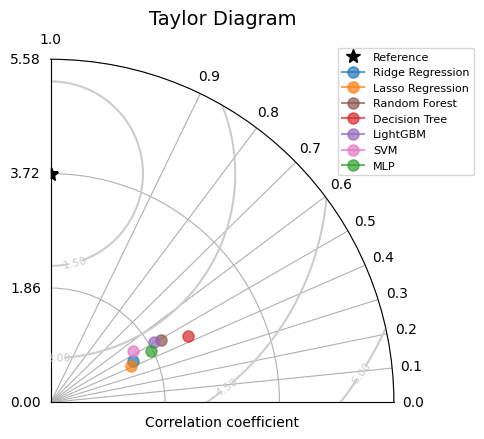

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===============================
# 📘 Classe Taylor Diagram
# ===============================
class TaylorDiagram:
    def __init__(self, refstd, fig=None, rect=111, label='Reference', srange=(0, 1.5)):
        self.refstd = refstd
        self.fig = fig or plt.figure(figsize=(12, 10))
        self.ax = self.fig.add_subplot(rect, polar=True)
        
        self.ax.set_theta_direction(-1)
        self.ax.set_theta_zero_location("N")
        self.ax.set_xlim(0, np.pi / 2)
        self.ax.set_ylim(0, srange[1] * refstd)

        corr_ticks = np.linspace(1, 0, 11)
        self.ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[f"{c:.1f}" for c in corr_ticks])
        self.ax.set_rgrids(np.linspace(0, srange[1]*refstd, 4), angle=135)
        self.ax.set_xlabel("Correlation coefficient")

        self.ax.plot(0, refstd, 'k*', markersize=10, label=label)

    def add_sample(self, stddev, corrcoef, label, marker='o', color=None):
        corrcoef = np.clip(corrcoef, -1, 1)
        theta = np.arccos(corrcoef)
        self.ax.plot(theta, stddev, marker=marker, color=color, label=label, markersize=8)

    def add_contours(self, levels=5, **kwargs):
        rs = np.linspace(0, 1.5 * self.refstd, 100)
        ts = np.linspace(0, np.pi / 2, 100)
        rs, ts = np.meshgrid(rs, ts, indexing='xy')
        rms = np.sqrt(self.refstd**2 + rs**2 - 2 * self.refstd * rs * np.cos(ts))
        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)
        self.ax.clabel(contours, inline=1, fontsize=8, fmt='%.2f')

    def show(self):
        self.ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=8, markerscale=1)
        plt.title("Taylor Diagram", fontsize=14)
        plt.tight_layout(pad=2.0)
        plt.show()


# ===============================
# 📊 Modelli e predizioni
# ===============================
models = {
    "Ridge Regression": (y_test_drop, y_pred_ridge),
    "Lasso Regression": (y_test_drop, y_pred_lasso),
    "Random Forest": (y_test, y_pred_rf),
    "Decision Tree": (y_test, y_pred_dt),
    "LightGBM": (y_test, y_pred_lgb),
    "SVM": (y_test_drop, y_pred_svr),
    "MLP": (y_test_drop, y_pred_dl.flatten())
}


# ===============================
# 🧹 Pulizia NaN e allineamento
# ===============================
def clean_nan_pairs(y_true, y_pred):
    """Rimuove coppie (y_true, y_pred) che contengono NaN e allinea le dimensioni"""
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = np.array(y_true[:n]), np.array(y_pred[:n])
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    return y_true[mask], y_pred[mask]


models_clean = {}
for name, (y_true, y_pred) in models.items():
    y_true_clean, y_pred_clean = clean_nan_pairs(y_true, y_pred)
    models_clean[name] = (y_true_clean, y_pred_clean)

# Diagnostica NaN e dimensioni
for name, (y_true, y_pred) in models.items():
    print(f"{name}: len(y_true)={len(y_true)}, len(y_pred)={len(y_pred)}, NaN={np.isnan(y_pred).sum()}")


# ===============================
# 🎨 Creazione Taylor Diagram
# ===============================
refstd = np.std(y_test[~np.isnan(y_test)])  # std del target di riferimento
taylor = TaylorDiagram(refstd)

colors = ['tab:blue', 'tab:orange', 'tab:brown', 'tab:red',
          'tab:purple', 'tab:pink', 'tab:green']
rgba_colors = [mcolors.to_rgba(c, alpha=0.7) for c in colors]

for (name, (y_true, y_pred)), color in zip(models_clean.items(), rgba_colors):
    if len(y_pred) == 0:
        print(f"⚠️ {name} escluso: nessun dato valido dopo pulizia NaN.")
        continue
    stddev = np.std(y_pred)
    corrcoef = np.corrcoef(y_true, y_pred)[0, 1]
    taylor.add_sample(stddev, corrcoef, label=name, color=color, marker='o')

taylor.add_contours(levels=5, colors='0.8')
taylor.show()
